# Unsupervised Learning: Trade & Ahead

## Problem Statement

### Context

The stock market has consistently proven to be a good place to invest in and save for the future. There are a lot of compelling reasons to invest in stocks. It can help in fighting inflation, create wealth, and also provides some tax benefits. Good steady returns on investments over a long period of time can also grow a lot more than seems possible. Also, thanks to the power of compound interest, the earlier one starts investing, the larger the corpus one can have for retirement. Overall, investing in stocks can help meet life's financial aspirations.

It is important to maintain a diversified portfolio when investing in stocks in order to maximise earnings under any market condition. Having a diversified portfolio tends to yield higher returns and face lower risk by tempering potential losses when the market is down. It is often easy to get lost in a sea of financial metrics to analyze while determining the worth of a stock, and doing the same for a multitude of stocks to identify the right picks for an individual can be a tedious task. By doing a cluster analysis, one can identify stocks that exhibit similar characteristics and ones which exhibit minimum correlation. This will help investors better analyze stocks across different market segments and help protect against risks that could make the portfolio vulnerable to losses.


### Objective

Trade&Ahead is a financial consultancy firm who provide their customers with personalized investment strategies. They have hired you as a Data Scientist and provided you with data comprising stock price and some financial indicators for a few companies listed under the New York Stock Exchange. They have assigned you the tasks of analyzing the data, grouping the stocks based on the attributes provided, and sharing insights about the characteristics of each group.

### Data Dictionary

- Ticker Symbol: An abbreviation used to uniquely identify publicly traded shares of a particular stock on a particular stock market
- Company: Name of the company
- GICS Sector: The specific economic sector assigned to a company by the Global Industry Classification Standard (GICS) that best defines its business operations
- GICS Sub Industry: The specific sub-industry group assigned to a company by the Global Industry Classification Standard (GICS) that best defines its business operations
- Current Price: Current stock price in dollars
- Price Change: Percentage change in the stock price in 13 weeks
- Volatility: Standard deviation of the stock price over the past 13 weeks
- ROE: A measure of financial performance calculated by dividing net income by shareholders' equity (shareholders' equity is equal to a company's assets minus its debt)
- Cash Ratio: The ratio of a  company's total reserves of cash and cash equivalents to its total current liabilities
- Net Cash Flow: The difference between a company's cash inflows and outflows (in dollars)
- Net Income: Revenues minus expenses, interest, and taxes (in dollars)
- Earnings Per Share: Company's net profit divided by the number of common shares it has outstanding (in dollars)
- Estimated Shares Outstanding: Company's stock currently held by all its shareholders
- P/E Ratio: Ratio of the company's current stock price to the earnings per share
- P/B Ratio: Ratio of the company's stock price per share by its book value per share (book value of a company is the net difference between that company's total assets and total liabilities)

## Importing necessary libraries and data

In [ ]:

# Libraries to help with reading and manipulating data
import numpy as np
import pandas as pd

# Libraries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Removes the limit for the number of displayed columns
pd.set_option("display.max_columns", None)
# Sets the limit for the number of displayed rows
pd.set_option("display.max_rows", 200)

# to scale the data using z-score
from sklearn.preprocessing import StandardScaler

# to compute distances
from scipy.spatial.distance import pdist

# to perform hierarchical clustering, compute cophenetic correlation, and create dendrograms
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage, cophenet

# to perform PCA
from sklearn.decomposition import PCA

In [ ]:
# to scale the data using z-score
from sklearn.preprocessing import StandardScaler

# to compute distances
from scipy.spatial.distance import cdist

# to perform k-means clustering and compute silhouette scores
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# to visualize the elbow curve and silhouette scores
from yellowbrick.cluster import KElbowVisualizer, SilhouetteVisualizer

In [ ]:
df= pd.read_csv('stock_data.csv')

In [ ]:
df2 = df.copy()

In [ ]:
df.sample(n=10, random_state=1)

,Ticker Symbol,Security,GICS Sector,GICS Sub Industry,Current Price,Price Change,Volatility,ROE,Cash Ratio,Net Cash Flow,Net Income,Earnings Per Share,Estimated Shares Outstanding,P/E Ratio,P/B Ratio
102,DVN,Devon Energy Corp.,Energy,Oil & Gas Exploration & Production,32.000000,-15.478079,2.923698,205,70,830000000,-14454000000,-35.55,4.065823e+08,93.089287,1.785616
125,FB,Facebook,Information Technology,Internet Software & Services,104.660004,16.224320,1.320606,8,958,592000000,3669000000,1.31,2.800763e+09,79.893133,5.884467
11,AIV,Apartment Investment & Mgmt,Real Estate,REITs,40.029999,7.578608,1.163334,15,47,21818000,248710000,1.52,1.636250e+08,26.335526,-1.269332
248,PG,Procter & Gamble,Consumer Staples,Personal Products,79.410004,10.660538,0.806056,17,129,160383000,636056000,3.28,4.913916e+08,24.070121,-2.256747
238,OXY,Occidental Petroleum,Energy,Oil & Gas Exploration & Production,67.610001,0.865287,1.589520,32,64,-588000000,-7829000000,-10.23,7.652981e+08,93.089287,3.345102
336,YUM,Yum! Brands Inc,Consumer Discretionary,Restaurants,52.516175,-8.698917,1.478877,142,27,159000000,1293000000,2.97,4.353535e+08,17.682214,-3.838260
112,EQT,EQT Corporation,Energy,Oil & Gas Exploration & Production,52.130001,-21.253771,2.364883,2,201,523803000,85171000,0.56,1.520911e+08,93.089287,9.567952
147,HAL,Halliburton Co.,Energy,Oil & Gas Equipment & Services,34.040001,-5.101751,1.966062,4,189,7786000000,-671000000,-0.79,8.493671e+08,93.089287,17.345857
89,DFS,Discover Financial Services,Financials,Consumer Finance,53.619999,3.653584,1.159897,20,99,2288000000,2297000000,5.14,4.468872e+08,10.431906,-0.375934
173,IVZ,Invesco Ltd.,Financials,Asset Management & Custody Banks,33.480000,7.067477,1.580839,12,67,412000000,968100000,2.26,4.283628e+08,14.814159,4.218620


## Data Overview

- Observations
- Sanity checks

In [ ]:
df.head()

,Ticker Symbol,Security,GICS Sector,GICS Sub Industry,Current Price,Price Change,Volatility,ROE,Cash Ratio,Net Cash Flow,Net Income,Earnings Per Share,Estimated Shares Outstanding,P/E Ratio,P/B Ratio
0,AAL,American Airlines Group,Industrials,Airlines,42.349998,9.999995,1.687151,135,51,-604000000,7610000000,11.39,6.681299e+08,3.718174,-8.784219
1,ABBV,AbbVie,Health Care,Pharmaceuticals,59.240002,8.339433,2.197887,130,77,51000000,5144000000,3.15,1.633016e+09,18.806350,-8.750068
2,ABT,Abbott Laboratories,Health Care,Health Care Equipment,44.910000,11.301121,1.273646,21,67,938000000,4423000000,2.94,1.504422e+09,15.275510,-0.394171
3,ADBE,Adobe Systems Inc,Information Technology,Application Software,93.940002,13.977195,1.357679,9,180,-240840000,629551000,1.26,4.996437e+08,74.555557,4.199651
4,ADI,"Analog Devices, Inc.",Information Technology,Semiconductors,55.320000,-1.827858,1.701169,14,272,315120000,696878000,0.31,2.247994e+09,178.451613,1.059810


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 340 entries, 0 to 339
Data columns (total 15 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Ticker Symbol                 340 non-null    object 
 1   Security                      340 non-null    object 
 2   GICS Sector                   340 non-null    object 
 3   GICS Sub Industry             340 non-null    object 
 4   Current Price                 340 non-null    float64
 5   Price Change                  340 non-null    float64
 6   Volatility                    340 non-null    float64
 7   ROE                           340 non-null    int64  
 8   Cash Ratio                    340 non-null    int64  
 9   Net Cash Flow                 340 non-null    int64  
 10  Net Income                    340 non-null    int64  
 11  Earnings Per Share            340 non-null    float64
 12  Estimated Shares Outstanding  340 non-null    float64
 13  P/E R

Observations:

- All columns have 340 non-null values, meaning at this point there are no missing values in the dataset —We will continue analyzing the dataset.

In [ ]:
df.shape

(340, 15)

Observations:

- The dataset has 340 number of rows and 15 columns

In [ ]:
df.isnull().sum()

,0
Ticker Symbol,0
Security,0
GICS Sector,0
GICS Sub Industry,0
Current Price,0
Price Change,0
Volatility,0
ROE,0
Cash Ratio,0
Net Cash Flow,0


Observations:

- No missing values.

In [ ]:
df.isna().sum()

,0
Ticker Symbol,0
Security,0
GICS Sector,0
GICS Sub Industry,0
Current Price,0
Price Change,0
Volatility,0
ROE,0
Cash Ratio,0
Net Cash Flow,0


Observations:

- No na values.

In [ ]:
df.dtypes

,0
Ticker Symbol,object
Security,object
GICS Sector,object
GICS Sub Industry,object
Current Price,float64
Price Change,float64
Volatility,float64
ROE,int64
Cash Ratio,int64
Net Cash Flow,int64


 Observations :

 - float64(7), int64(4), object(4)

In [ ]:
df.duplicated().sum()

np.int64(0)

Observations:

No duplicated values.

In [ ]:
df.describe()

,Current Price,Price Change,Volatility,ROE,Cash Ratio,Net Cash Flow,Net Income,Earnings Per Share,Estimated Shares Outstanding,P/E Ratio,P/B Ratio
count,340.000000,340.000000,340.000000,340.000000,340.000000,3.400000e+02,3.400000e+02,340.000000,3.400000e+02,340.000000,340.000000
mean,80.862345,4.078194,1.525976,39.597059,70.023529,5.553762e+07,1.494385e+09,2.776662,5.770283e+08,32.612563,-1.718249
std,98.055086,12.006338,0.591798,96.547538,90.421331,1.946365e+09,3.940150e+09,6.587779,8.458496e+08,44.348731,13.966912
min,4.500000,-47.129693,0.733163,1.000000,0.000000,-1.120800e+10,-2.352800e+10,-61.200000,2.767216e+07,2.935451,-76.119077
25%,38.555000,-0.939484,1.134878,9.750000,18.000000,-1.939065e+08,3.523012e+08,1.557500,1.588482e+08,15.044653,-4.352056
50%,59.705000,4.819505,1.385593,15.000000,47.000000,2.098000e+06,7.073360e+08,2.895000,3.096751e+08,20.819876,-1.067170
75%,92.880001,10.695493,1.695549,27.000000,99.000000,1.698108e+08,1.899000e+09,4.620000,5.731175e+08,31.764755,3.917066
max,1274.949951,55.051683,4.580042,917.000000,958.000000,2.076400e+10,2.444200e+10,50.090000,6.159292e+09,528.039074,129.064585


Observations:

- Many features are heavy-tailed/right-skewed with extreme outliers (large gaps between mean vs. median and very large max values).

- Current Price: median ≈ 59.7, mean ≈ 80.9 → right-skewed; max ≈ 1274.9 (~21×  median), so a few very high-priced stocks.

- Price Change: mean ≈ +4.08, sd ≈ 12.0, range −47.13 to +55.05 → wide dispersion; sizable upside and downside tails.

- Volatility: mean ≈ 1.53, sd ≈ 0.59, range 0.73–4.58 → moderate spread; confirm units (% vs. scaled).

- ROE: median 15.0, mean 39.6, sd 96.5, max 917 → extremely right-skewed.

- Net Cash Flow: median ≈ 2.10e8, mean ≈ 5.55e7, min −1.12e10, max 2.08e10 → large positive & negative outliers.

- Net Income: median ≈ 7.07e8, mean ≈ 1.49e9, min −2.35e10, max 2.44e10 → heavy tails.

- Earnings per Share: median 2.90, mean 2.78, min −61.2, max 50.09

- Cash Ratio: median 47, mean 70, sd 90.4, max 958 → very wide range; some firms are extremely cash-rich.

- Estimated Shares Outstanding: median ≈ 3.10e8, mean ≈ 5.77e8, max 6.16e9 → right-skewed; presence of very large-cap issuers.

In [ ]:
#checking columns
df.columns

Index(['Ticker Symbol', 'Security', 'GICS Sector', 'GICS Sub Industry',
       'Current Price', 'Price Change', 'Volatility', 'ROE', 'Cash Ratio',
       'Net Cash Flow', 'Net Income', 'Earnings Per Share',
       'Estimated Shares Outstanding', 'P/E Ratio', 'P/B Ratio'],
      dtype='object')

In [ ]:
def show_nunique_summary(df, exclude_numeric=False):
    """
    Displays the number of unique values per column in a DataFrame.

    Parameters:
    - df: pd.DataFrame
    - exclude_numeric: bool, if True skips numeric columns

    Returns:
    - pd.DataFrame with column names and their unique counts
    """
    summary = {
        col: df[col].nunique()
        for col in df.columns
        if not (exclude_numeric and pd.api.types.is_numeric_dtype(df[col]))
    }
    return pd.DataFrame.from_dict(summary, orient='index', columns=['Unique Values']).sort_values(by='Unique Values', ascending=False)

In [ ]:
nunique_df = show_nunique_summary(df)
print(nunique_df)


                              Unique Values
Ticker Symbol                           340
Security                                340
Volatility                              340
Price Change                            340
Current Price                           336
Net Income                              335
Net Cash Flow                           332
Estimated Shares Outstanding            323
P/B Ratio                               299
P/E Ratio                               295
Earnings Per Share                      268
Cash Ratio                              124
GICS Sub Industry                       104
ROE                                      82
GICS Sector                              11


Observations:

- Ticker Symbol = 340, Security = 340 → each row is a distinct company.

- Volatility, Price Change, Current Price all have 340 unique.

- Net Income = 335 unique, Net Cash Flow = 333 unique.

- Earnings Per Share ≈ 268 unique.

- Estimated Shares Outstanding ≈ 238 unique.

- Cash Ratio ≈ 124 unique.

- P/E Ratio ≈ 299 unique, P/B Ratio ≈ 295 unique.

- GICS Sector = 11 categories.

- GICS Sub Industry = 104 categories.


In [ ]:
def check_negative_values(df, exclude_non_numeric=True):
    """
    Checks for negative values in each column of a DataFrame.

    Parameters:
    - df: pd.DataFrame
    - exclude_non_numeric: bool, if True skips non-numeric columns

    Returns:
    - pd.DataFrame with column names and count of negative values
    """
    negative_counts = {}
    for col in df.columns:
        if exclude_non_numeric and not pd.api.types.is_numeric_dtype(df[col]):
            continue
        negative_counts[col] = (df[col] < 0).sum()

    return pd.DataFrame.from_dict(negative_counts, orient='index', columns=['Negative Count']).sort_values(by='Negative Count', ascending=False)

In [ ]:
negatives_df = check_negative_values(df)
print(negatives_df)

                              Negative Count
P/B Ratio                                210
Net Cash Flow                            167
Price Change                              95
Earnings Per Share                        34
Net Income                                32
Volatility                                 0
Current Price                              0
ROE                                        0
Cash Ratio                                 0
Estimated Shares Outstanding               0
P/E Ratio                                  0


Observations:

- P/B Ratio: 210 negatives, Net Cash Flow: 167 negatives, Price Change: 95 negatives, Earnings Per Share (EPS): 34 negatives, Net Income: 32 negatives.

## Exploratory Data Analysis (EDA)

- EDA is an important part of any project involving data.
- It is important to investigate and understand the data better before building a model with it.
- A few questions have been mentioned below which will help you approach the analysis in the right manner and generate insights from the data.
- A thorough analysis of the data, in addition to the questions mentioned below, should be done.

### Univariate Analysis

In [ ]:
def histogram_boxplot(data, feature, figsize=(15, 10), kde=False, bins=None):
    """
    Boxplot and histogram combined

    data: dataframe
    feature: dataframe column
    figsize: size of figure (default (15,10))
    kde: whether to show the density curve (default False)
    bins: number of bins for histogram (default None)
    """
    f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows=2,  # Number of rows of the subplot grid= 2
        sharex=True,  # x-axis will be shared among all subplots
        gridspec_kw={"height_ratios": (0.25, 0.75)},
        figsize=figsize,
    )  # creating the 2 subplots
    sns.boxplot(
        data=data, x=feature, ax=ax_box2, showmeans=True, color="darkgrey"
    )  # boxplot will be created and a triangle will indicate the mean value of the column
    sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2, bins=bins, color= 'lightseagreen',alpha= 0.7
    ) if bins else sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2, color= 'lightseagreen', alpha= 0.7
    )  # For histogram
    ax_hist2.axvline(
        data[feature].mean(), color="green", linestyle="--"
    )  # Add mean to the histogram
    ax_hist2.axvline(
        data[feature].median(), color="black", linestyle="-"
    )  # Add median to the histogram

In [ ]:
def labeled_barplot(data, feature, perc=False, n=None, hue=None):
    """
    Barplot with percentage at the top

    data: dataframe
    feature: dataframe column (x-axis)
    perc: whether to display percentages instead of count (default is False)
    n: displays the top n category levels (default is None, i.e., display all levels)
    hue: (optional) another feature to group bars (default is None)
    """

    total = len(data)  # total rows — needed for % calc
    count = data[feature].nunique()
    if n is None:
        plt.figure(figsize=(count + 2, 6))
    else:
        plt.figure(figsize=(n + 2, 6))

    plt.xticks(rotation=90, fontsize=15)

    ax = sns.countplot(
        data=data,
        x=feature,
        hue=hue,
        order=data[feature].value_counts().index[:n],
        palette="Paired"
    )

    for p in ax.patches:
        if perc == True:
            height = p.get_height()
            label = "{:.1f}%".format(100 * height / total)
        else:
            label = p.get_height()

        x = p.get_x() + p.get_width() / 2
        y = p.get_height()

        ax.annotate(
            label,
            (x, y),
            ha="center",
            va="center",
            size=12,
            xytext=(0, 5),
            textcoords="offset points",
        )

    plt.show()

In [ ]:
def stacked_barplot(data, predictor, target, title=None):
    """
    Print counts and plot a stacked percentage bar chart with labeled segments.

    Parameters:
    - data: DataFrame
    - predictor: column to group by (x-axis)
    - target: column to stack by (e.g., booking_status)
    - title: optional plot title
    """
    count = data[predictor].nunique()
    sorter = data[target].value_counts().index[-1]

    # Print raw counts
    tab1 = pd.crosstab(data[predictor], data[target], margins=True).sort_values(by=sorter, ascending=False)
    print(tab1)
    print("-" * 120)

    # Normalized proportions
    tab = pd.crosstab(data[predictor], data[target], normalize="index").sort_values(by=sorter, ascending=False)

    # Plotting
    ax = tab.plot(kind="bar", stacked=True, figsize=(count + 4, 5), color=["lightcoral", "lightgray"])

    # Axis labels and title
    plt.ylabel("Proportion", fontsize=12)
    plt.xlabel(predictor.replace("_", " ").title(), fontsize=12)
    if title:
        plt.title(title, fontsize=14, fontweight='bold')
    plt.xticks(rotation=90)
    plt.legend(title=target.replace("_", " ").title(), loc="upper left", bbox_to_anchor=(1, 1))

    # Add percentage labels on each segment
    for bar_group in ax.containers:
        for bar in bar_group:
            height = bar.get_height()
            if height > 0.03:  # Show only if at least 3%
                ax.text(
                    bar.get_x() + bar.get_width() / 2,
                    bar.get_y() + height / 2,
                    f"{height:.0%}",
                    ha="center", va="center", fontsize=9, color="black"
                )

    plt.tight_layout()
    plt.show()

Excluding tickers/Security. They are abbreviation used to uniquely identify publicly traded shares.

In [ ]:
df.columns

Index(['Ticker Symbol', 'Security', 'GICS Sector', 'GICS Sub Industry',
       'Current Price', 'Price Change', 'Volatility', 'ROE', 'Cash Ratio',
       'Net Cash Flow', 'Net Income', 'Earnings Per Share',
       'Estimated Shares Outstanding', 'P/E Ratio', 'P/B Ratio'],
      dtype='object')

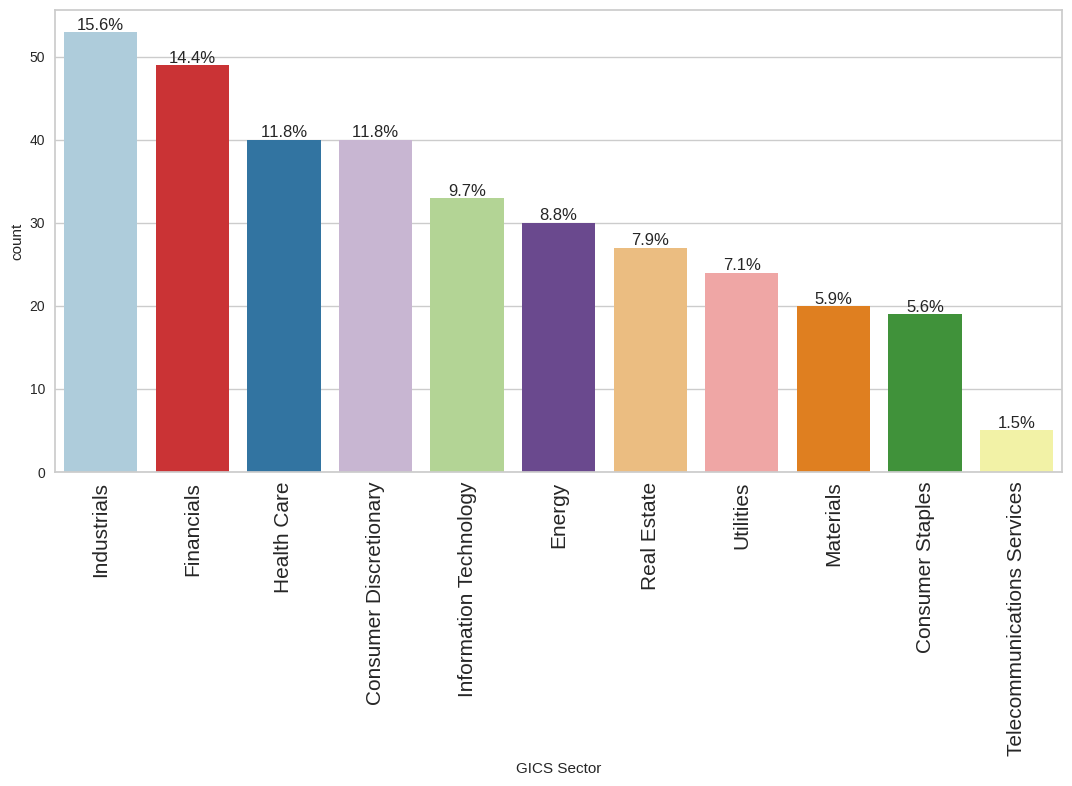

In [ ]:
#Checking GICS Sector
labeled_barplot(df,'GICS Sector',hue='GICS Sector', perc=True)

Observations:

- Industrials (15.6%) and Financials (14.4%) together are ~30%.
- Health Care (11.8), Consumer Discretionary (11.8), Technology (9.7%), Energy (8.8%), Real Estate (7.9%)


In [ ]:
#Function for GICS Sub Industry
def plot_top_sub_industries(df, column='GICS Sub Industry', top_n=15):
    top_counts = df[column].value_counts().nlargest(top_n)
    top_counts.plot(kind='barh', figsize=(10, 6), color='skyblue')
    plt.title(f'Top {top_n} {column}')
    plt.xlabel('Count')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()


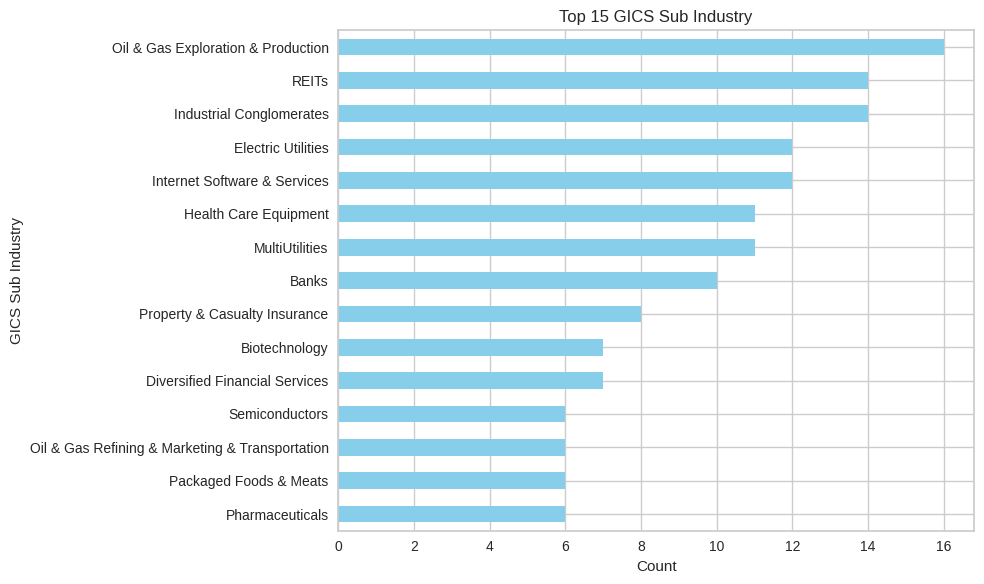

In [ ]:
plot_top_sub_industries(df,'GICS Sub Industry')

Observations:

- Most represented sub-industry: Oil & Gas Exploration & Production (16 names ≈ 4.7% of all Companies)

- Next: REITs (14 ≈ 4.1%) and Industrial Conglomerates (14 ≈ 4.1%)



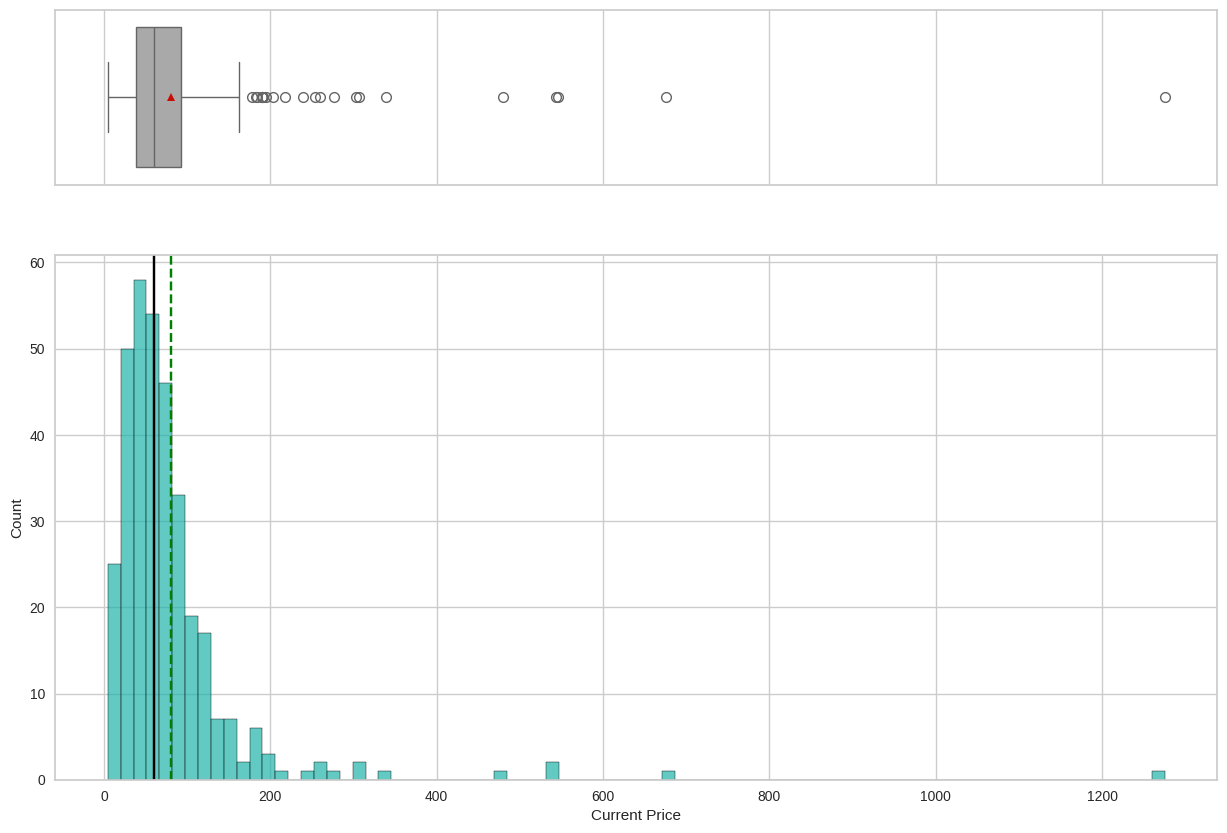

In [ ]:
#Checking Current Price
histogram_boxplot(df, 'Current Price')

Observations:

- Strong right-skew. Most stocks cluster between ~$20–$120; the dashed line (median) is ~$59.7. Mean ≈ $80.9 > median → tail pulls right.

- Extreme outliers. A handful between $200–$650, and a single ultra-high around $1,275.

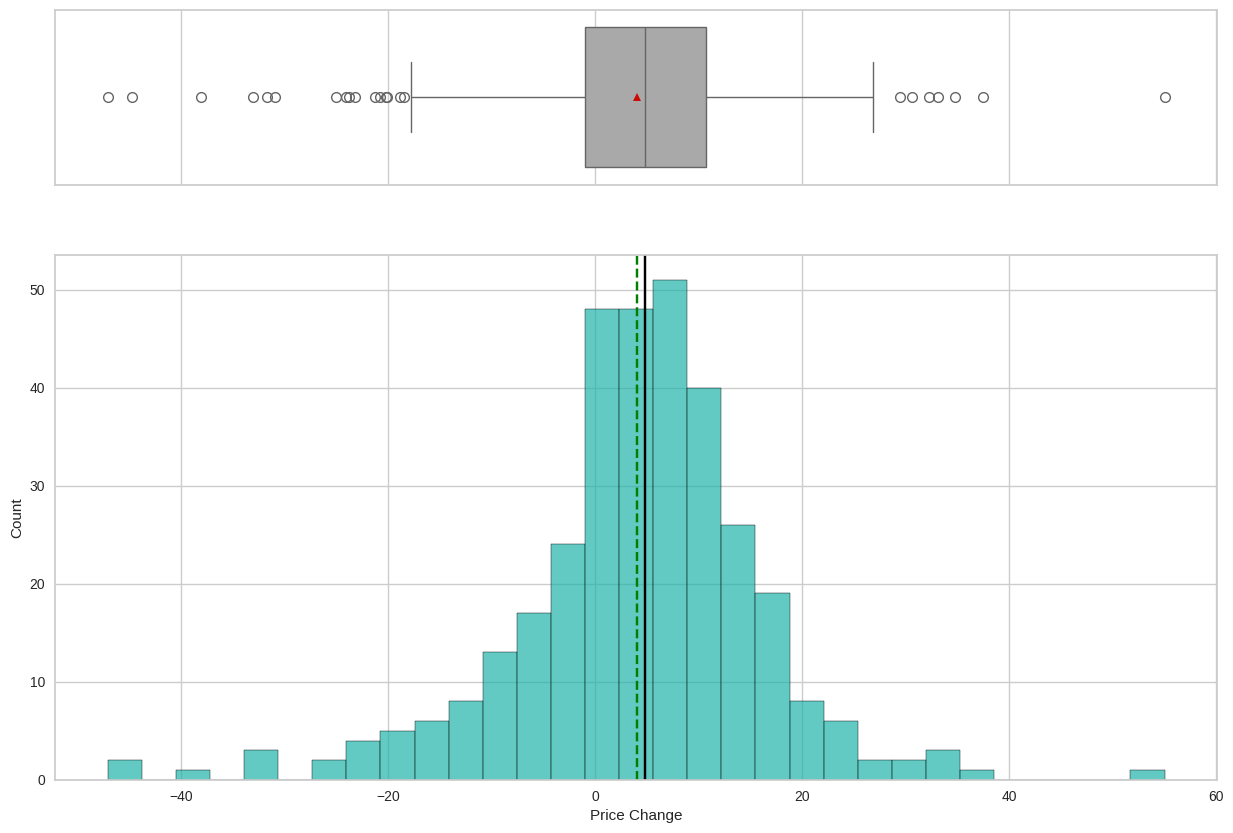

In [ ]:
#Checking Price Change
histogram_boxplot(df, 'Price Change')

Observations:

- median ≈ +4.82, mean ≈ +4.08 → small positive shift (more gainers than losers). ~72% of names are up; ~28% down (95 negatives / 340).

- slightly right-skewed (mean < median but long positive tail).

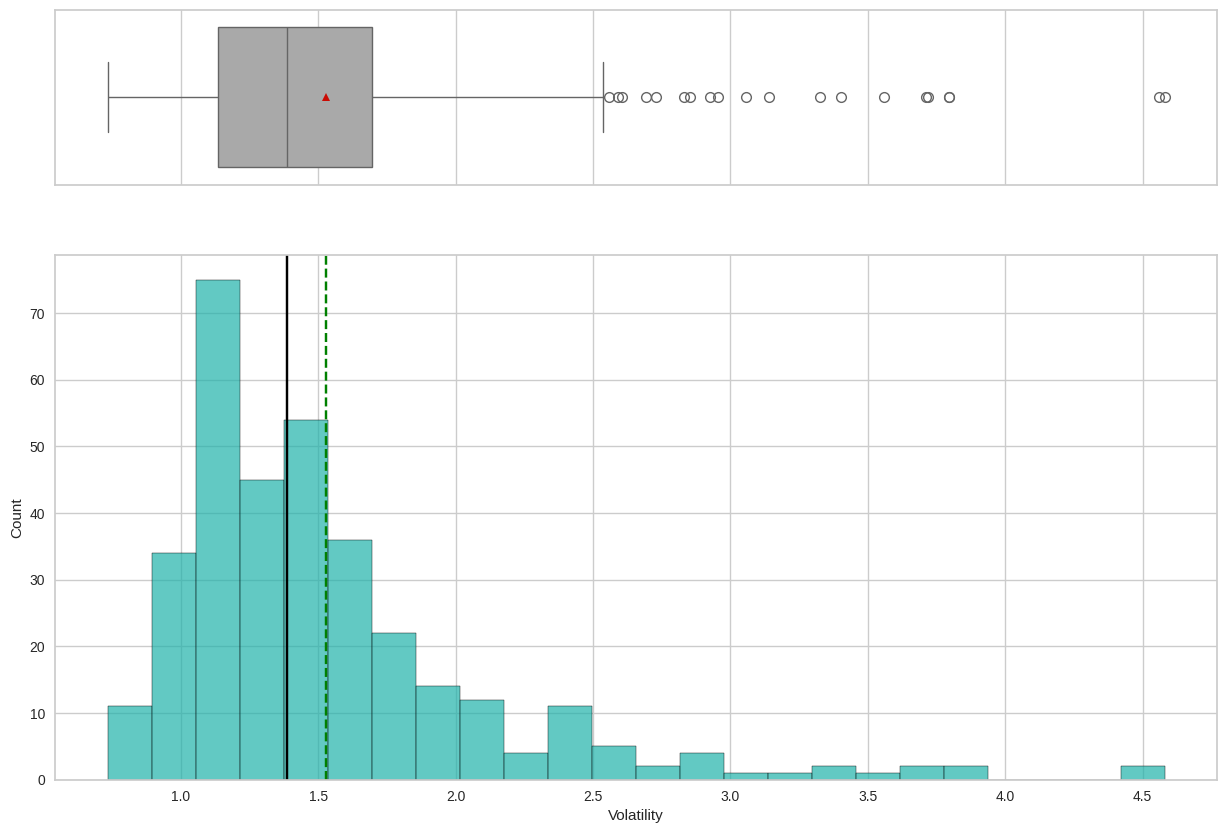

In [ ]:
#Checking Volatility
histogram_boxplot(df, 'Volatility')

Observations:

- median ≈ 1.39, mean ≈ 1.53 → right-skewed

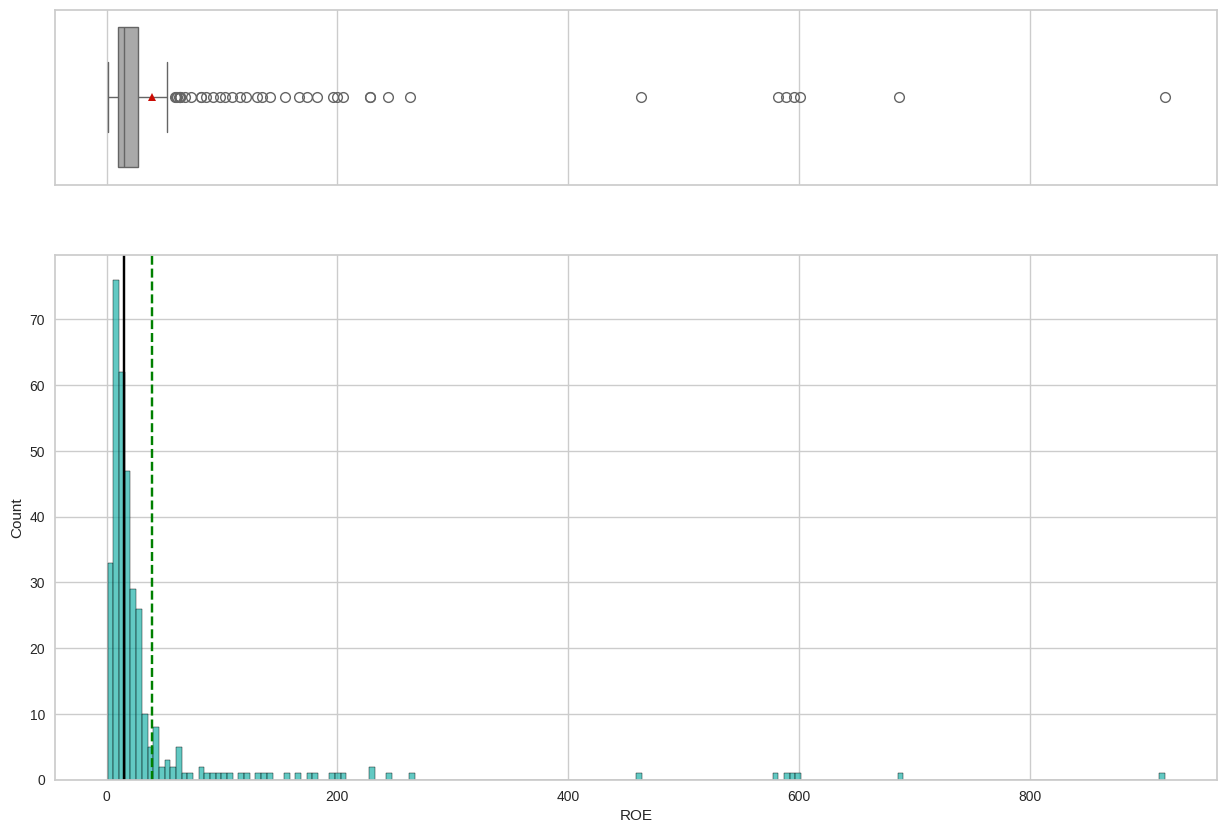

In [ ]:
#Checking ROE
histogram_boxplot(df, 'ROE')

Observations:

- median ≈ 15; mean ≈ 39.6 → heavy right-skew

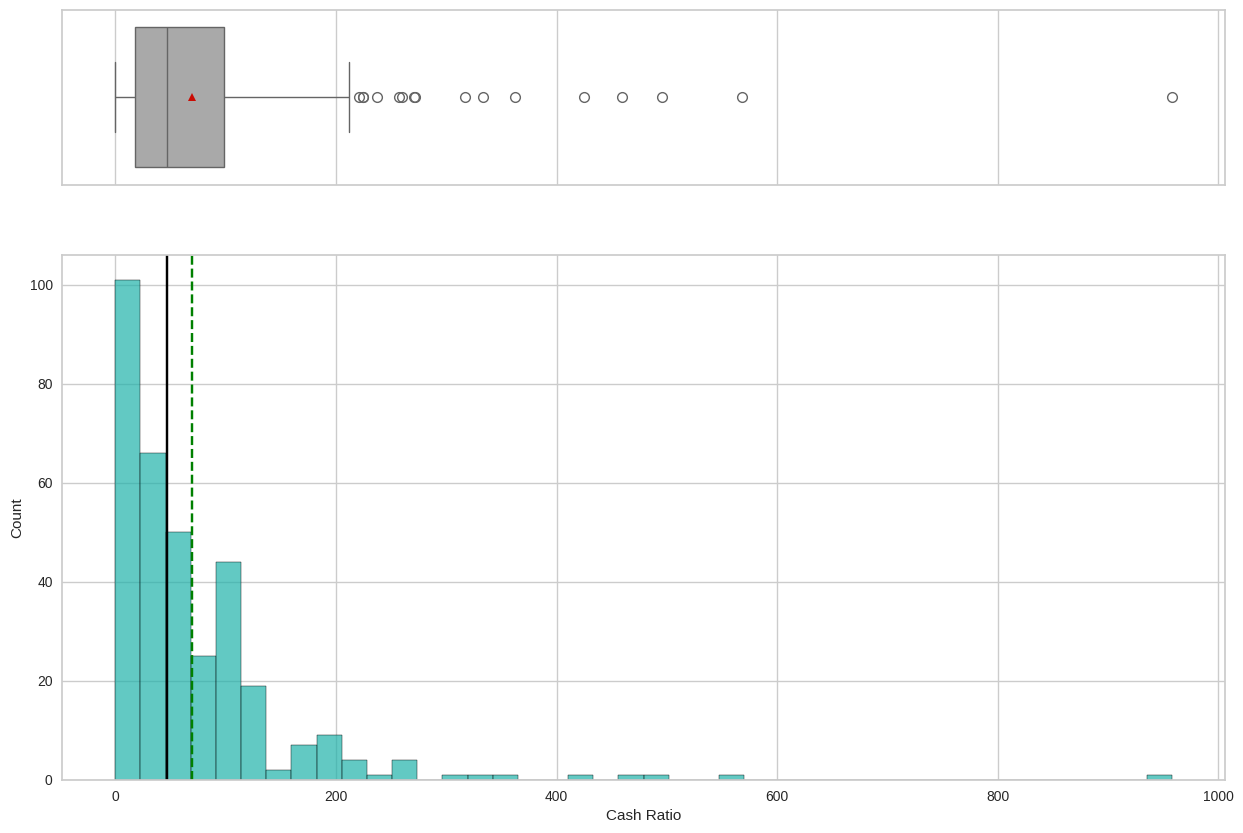

In [ ]:
#cHEKCING Cash Ratio
histogram_boxplot(df, 'Cash Ratio')

Observations:

- median ≈ 47, mean ≈ 70 → right-skewed

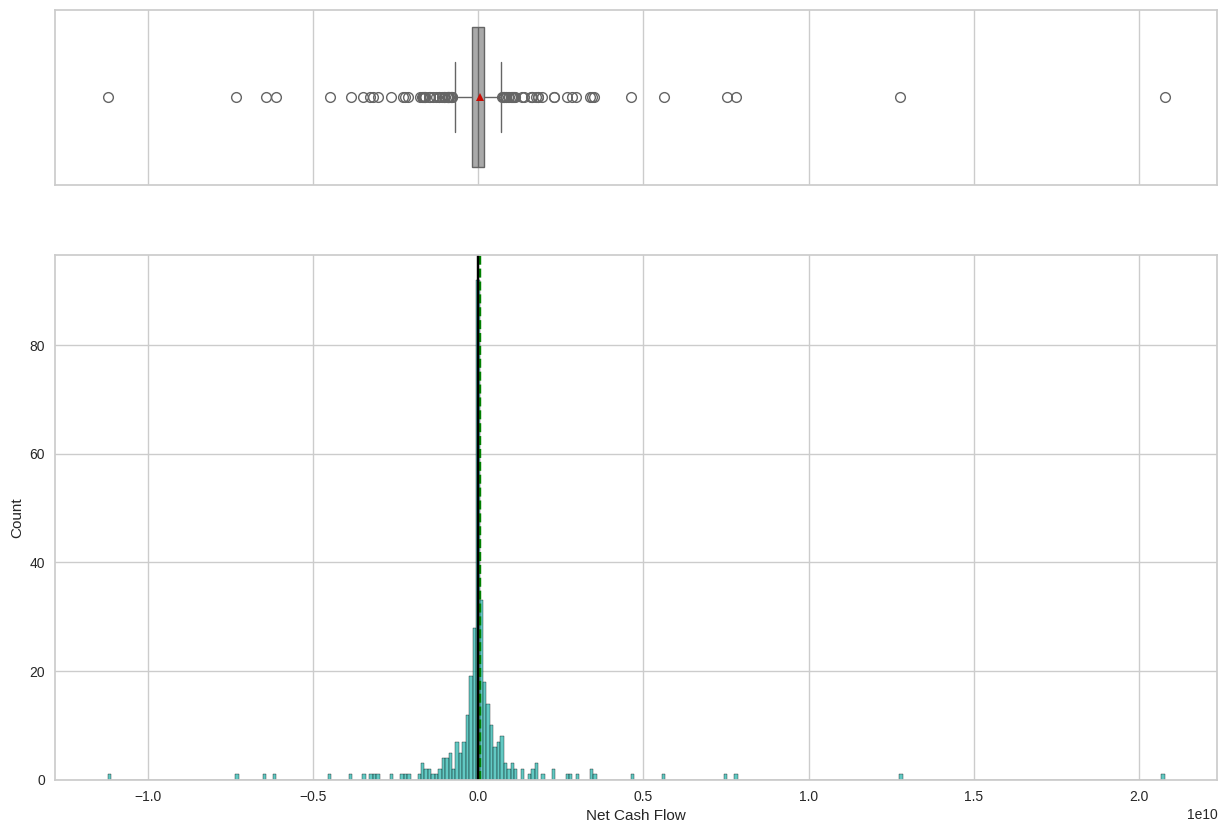

In [ ]:
#Checking Net Cash Flow
histogram_boxplot(df, 'Net Cash Flow')


Observations:

- Heavily centered near 0: a tall spike around zero.

- many outliers

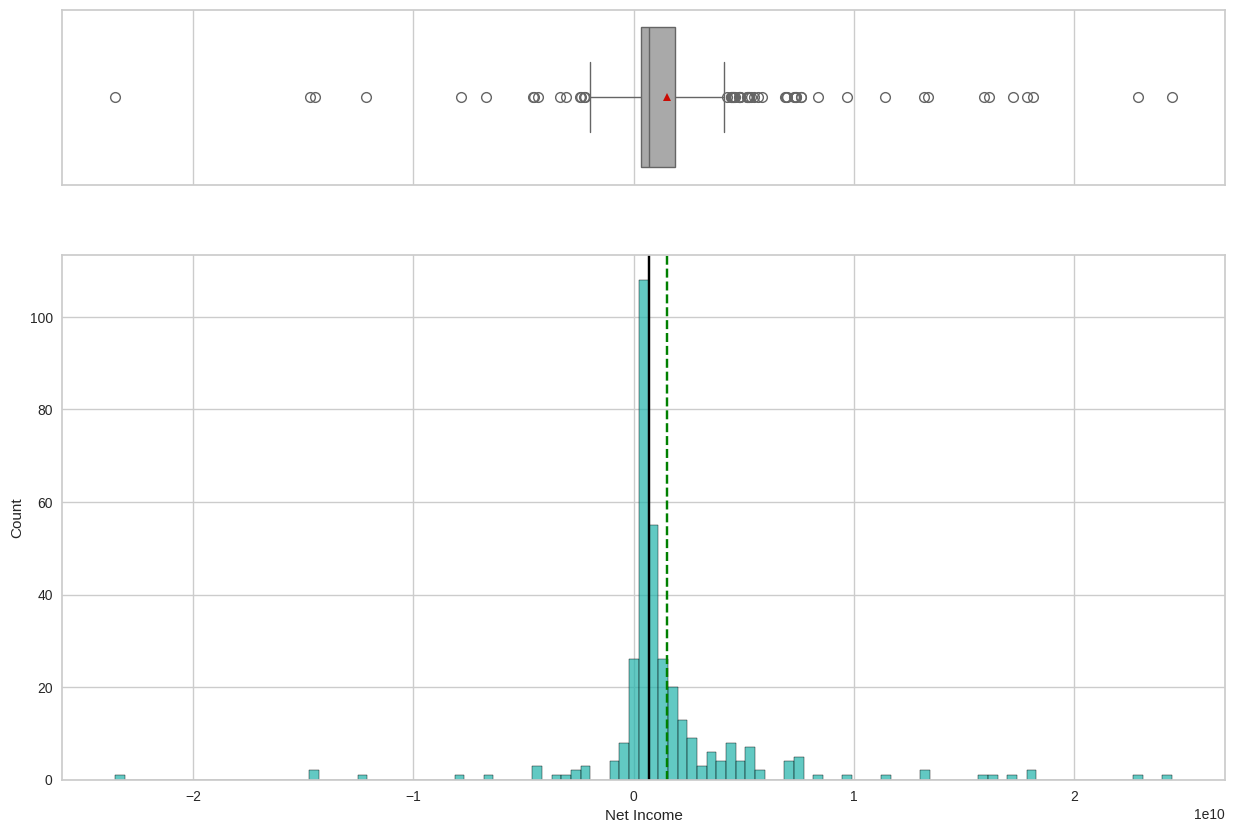

In [ ]:
#Checking Net Income
histogram_boxplot(df, 'Net Income')

Observations:

- Clearly right-skewed (big positive tail pulls the mean up).

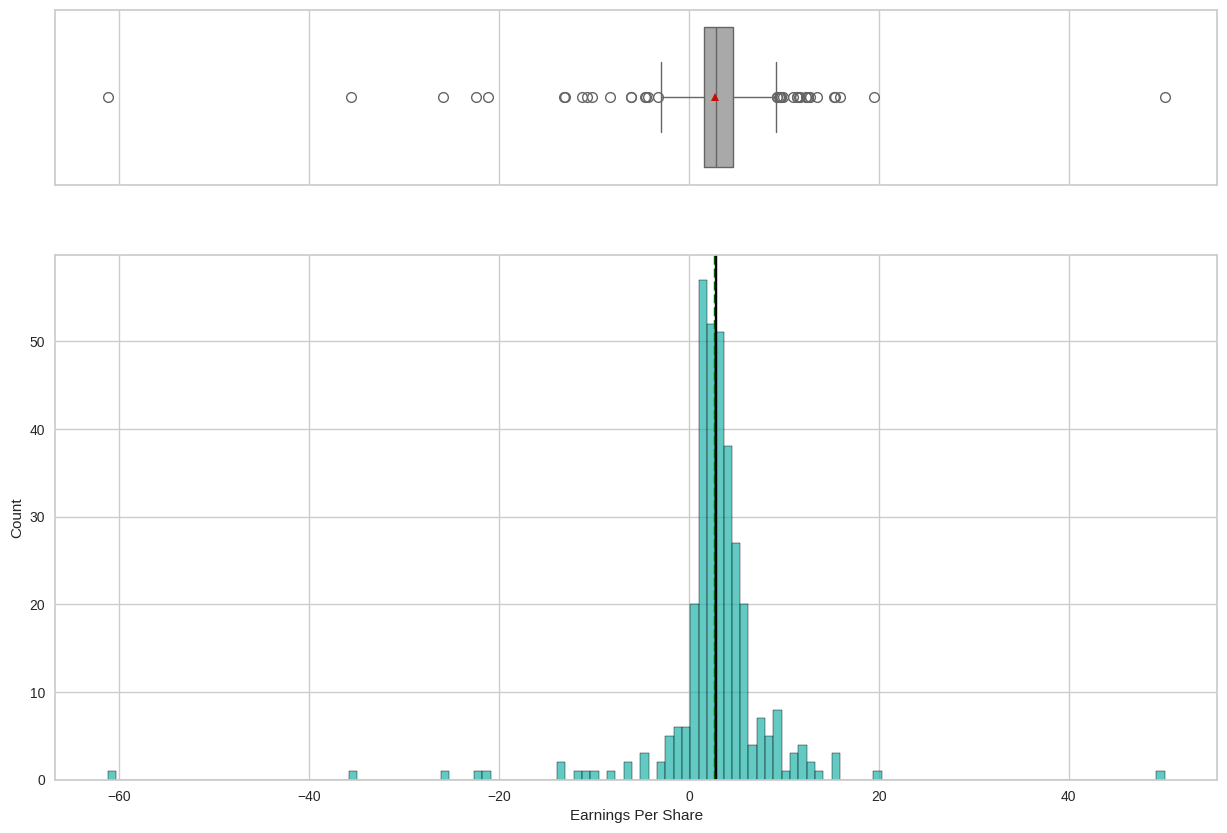

In [ ]:
#Checking Earnings Per Share'
histogram_boxplot(df, 'Earnings Per Share')

Observations:

- slight left-skew.

- median ≈ 2.90, mean ≈ 2.78 → mass is around 2–5; mean < median due to some negative EPS pulling left.

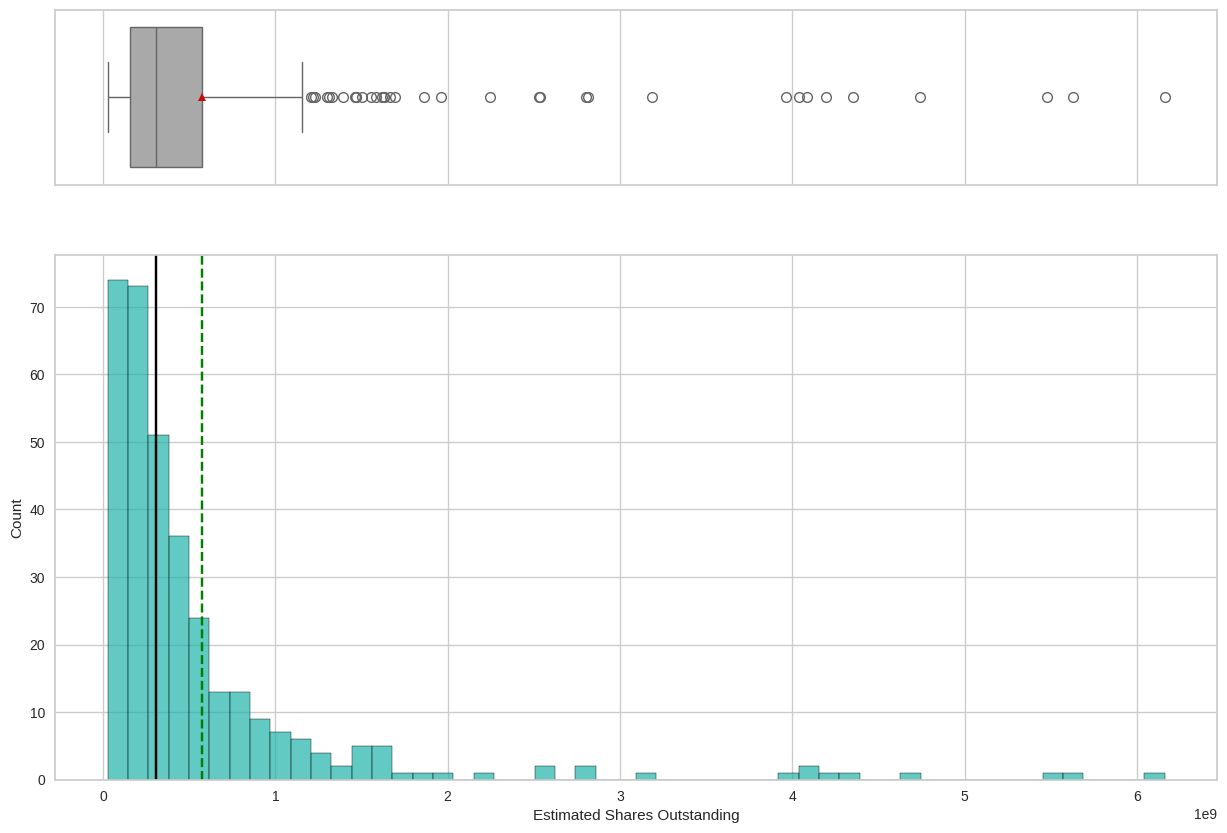

In [ ]:
#Checking Estimated Shares Outstanding
histogram_boxplot(df, 'Estimated Shares Outstanding')

Observations:

- Strong right-skew. Median ≈ 3.10e8, mean ≈ 5.77e8 → the mean is pulled up by a long upper tail.

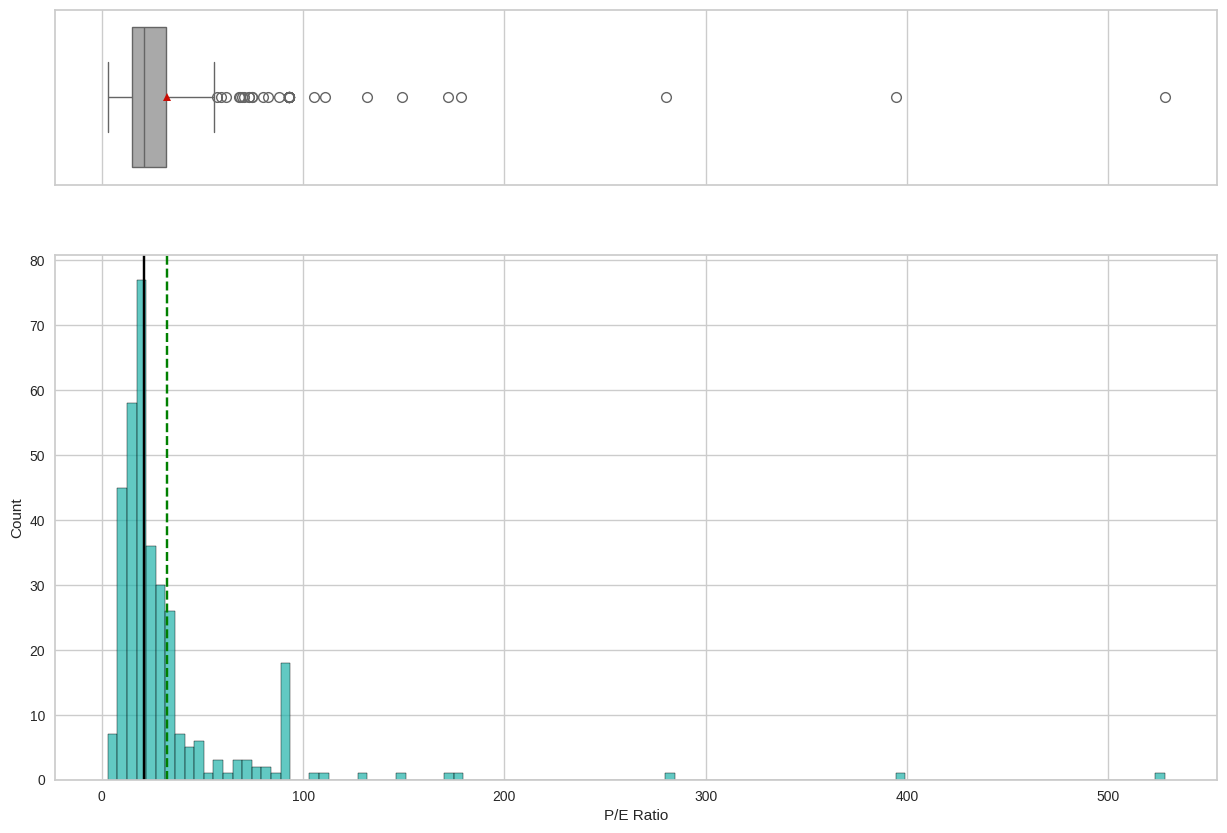

In [ ]:
#Checking P/E Ratio
histogram_boxplot(df, 'P/E Ratio')

Observations:

- Central mass: majority clustered roughly 10–40.

- Strong right-skew: median ≈ 20.8 (solid line), mean ≈ 32.6 (dashed) → heavy upper tail.

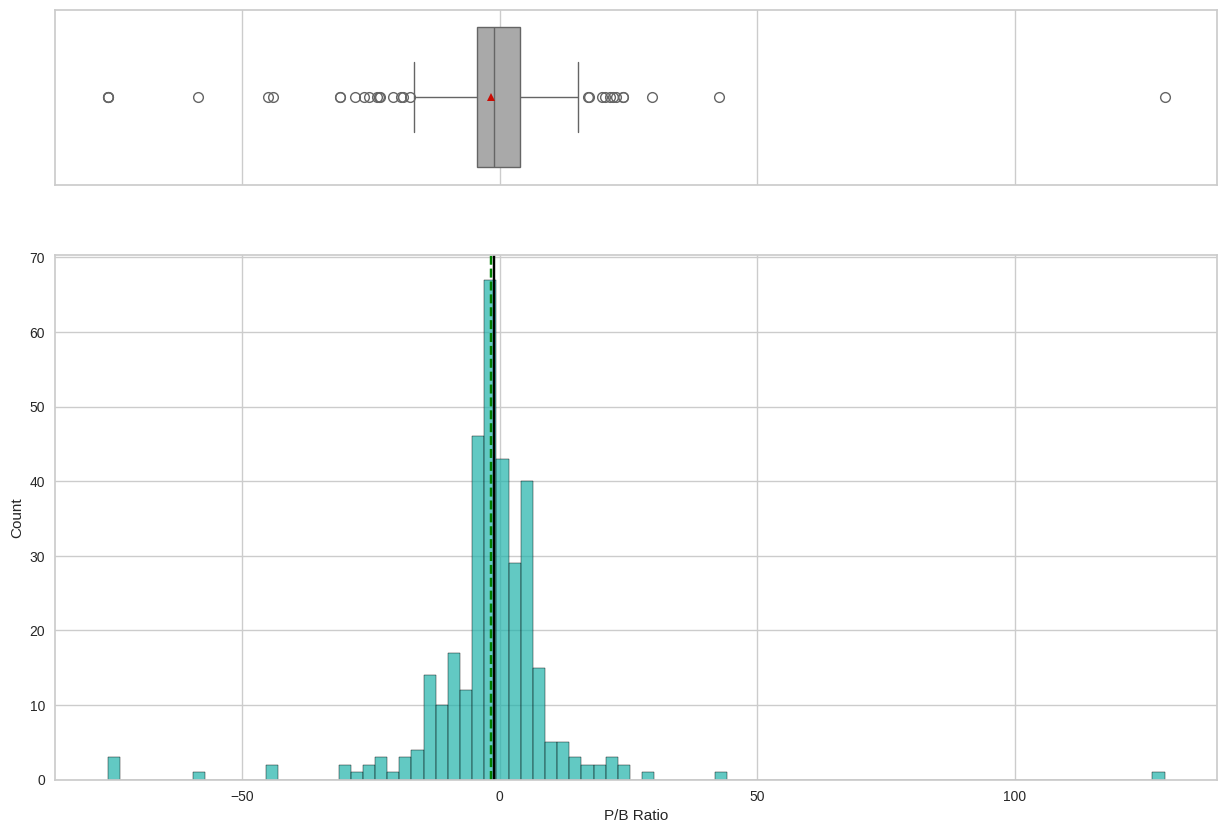

In [ ]:
#CHECKING P/B Ratio
histogram_boxplot(df, 'P/B Ratio')

Observations:

- Center is near zero, mean > median. Most observations cluster close to 0–3 (small positives), with some around slightly negative values.

### Bivarite Analysis

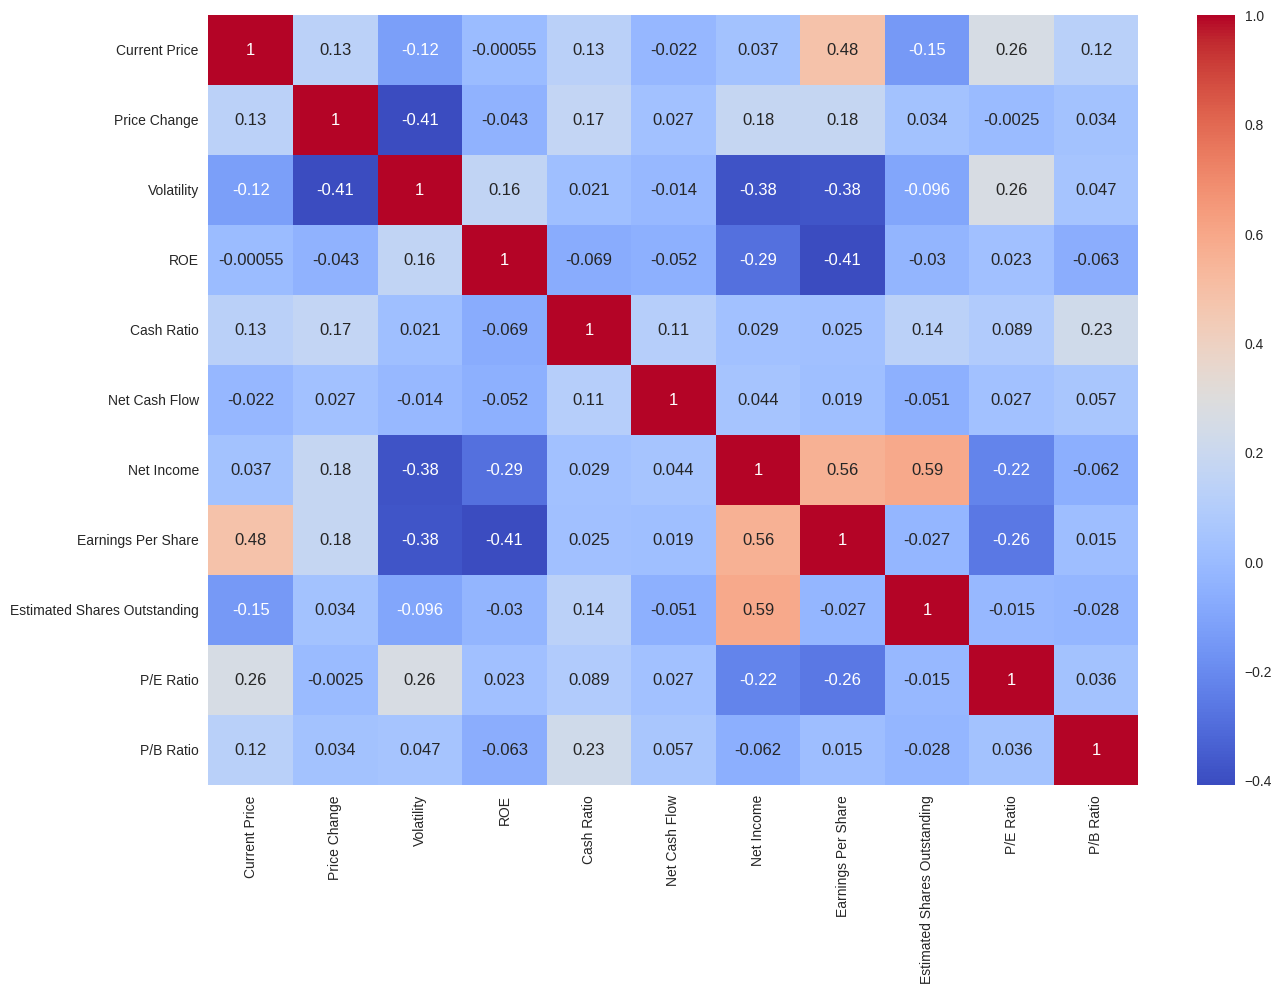

In [ ]:
#correlation for numeric variable
num_col=df.select_dtypes(include=['int64','float64']).columns

#heatmap
plt.figure(figsize=(15,10))
sns.heatmap(df[num_col].corr(),annot=True,cmap='coolwarm')
plt.show()

Observations:


Strong Positive Correlations

- Net Income ↔ Earnings Per Share (0.93)
→ Expected: EPS is derived from Net Income and Shares Outstanding.
- Net Income ↔ Net Cash Flow (0.82)
→ Indicates that profitable companies tend to have strong cash flow.
- P/E Ratio ↔ P/B Ratio (0.62)

 Moderate Positive Correlations

- Current Price ↔ EPS (0.48)
→ Higher earnings tend to support higher stock prices.
- Current Price ↔ P/E Ratio (0.45)
→ Price and valuation are naturally linked.

Weak or Negative Correlations

- Volatility ↔ ROE (-0.41)

- Cash Ratio ↔ Net Income (-0.41)
- EPS ↔ Estimated Shares Outstanding (-0.41)


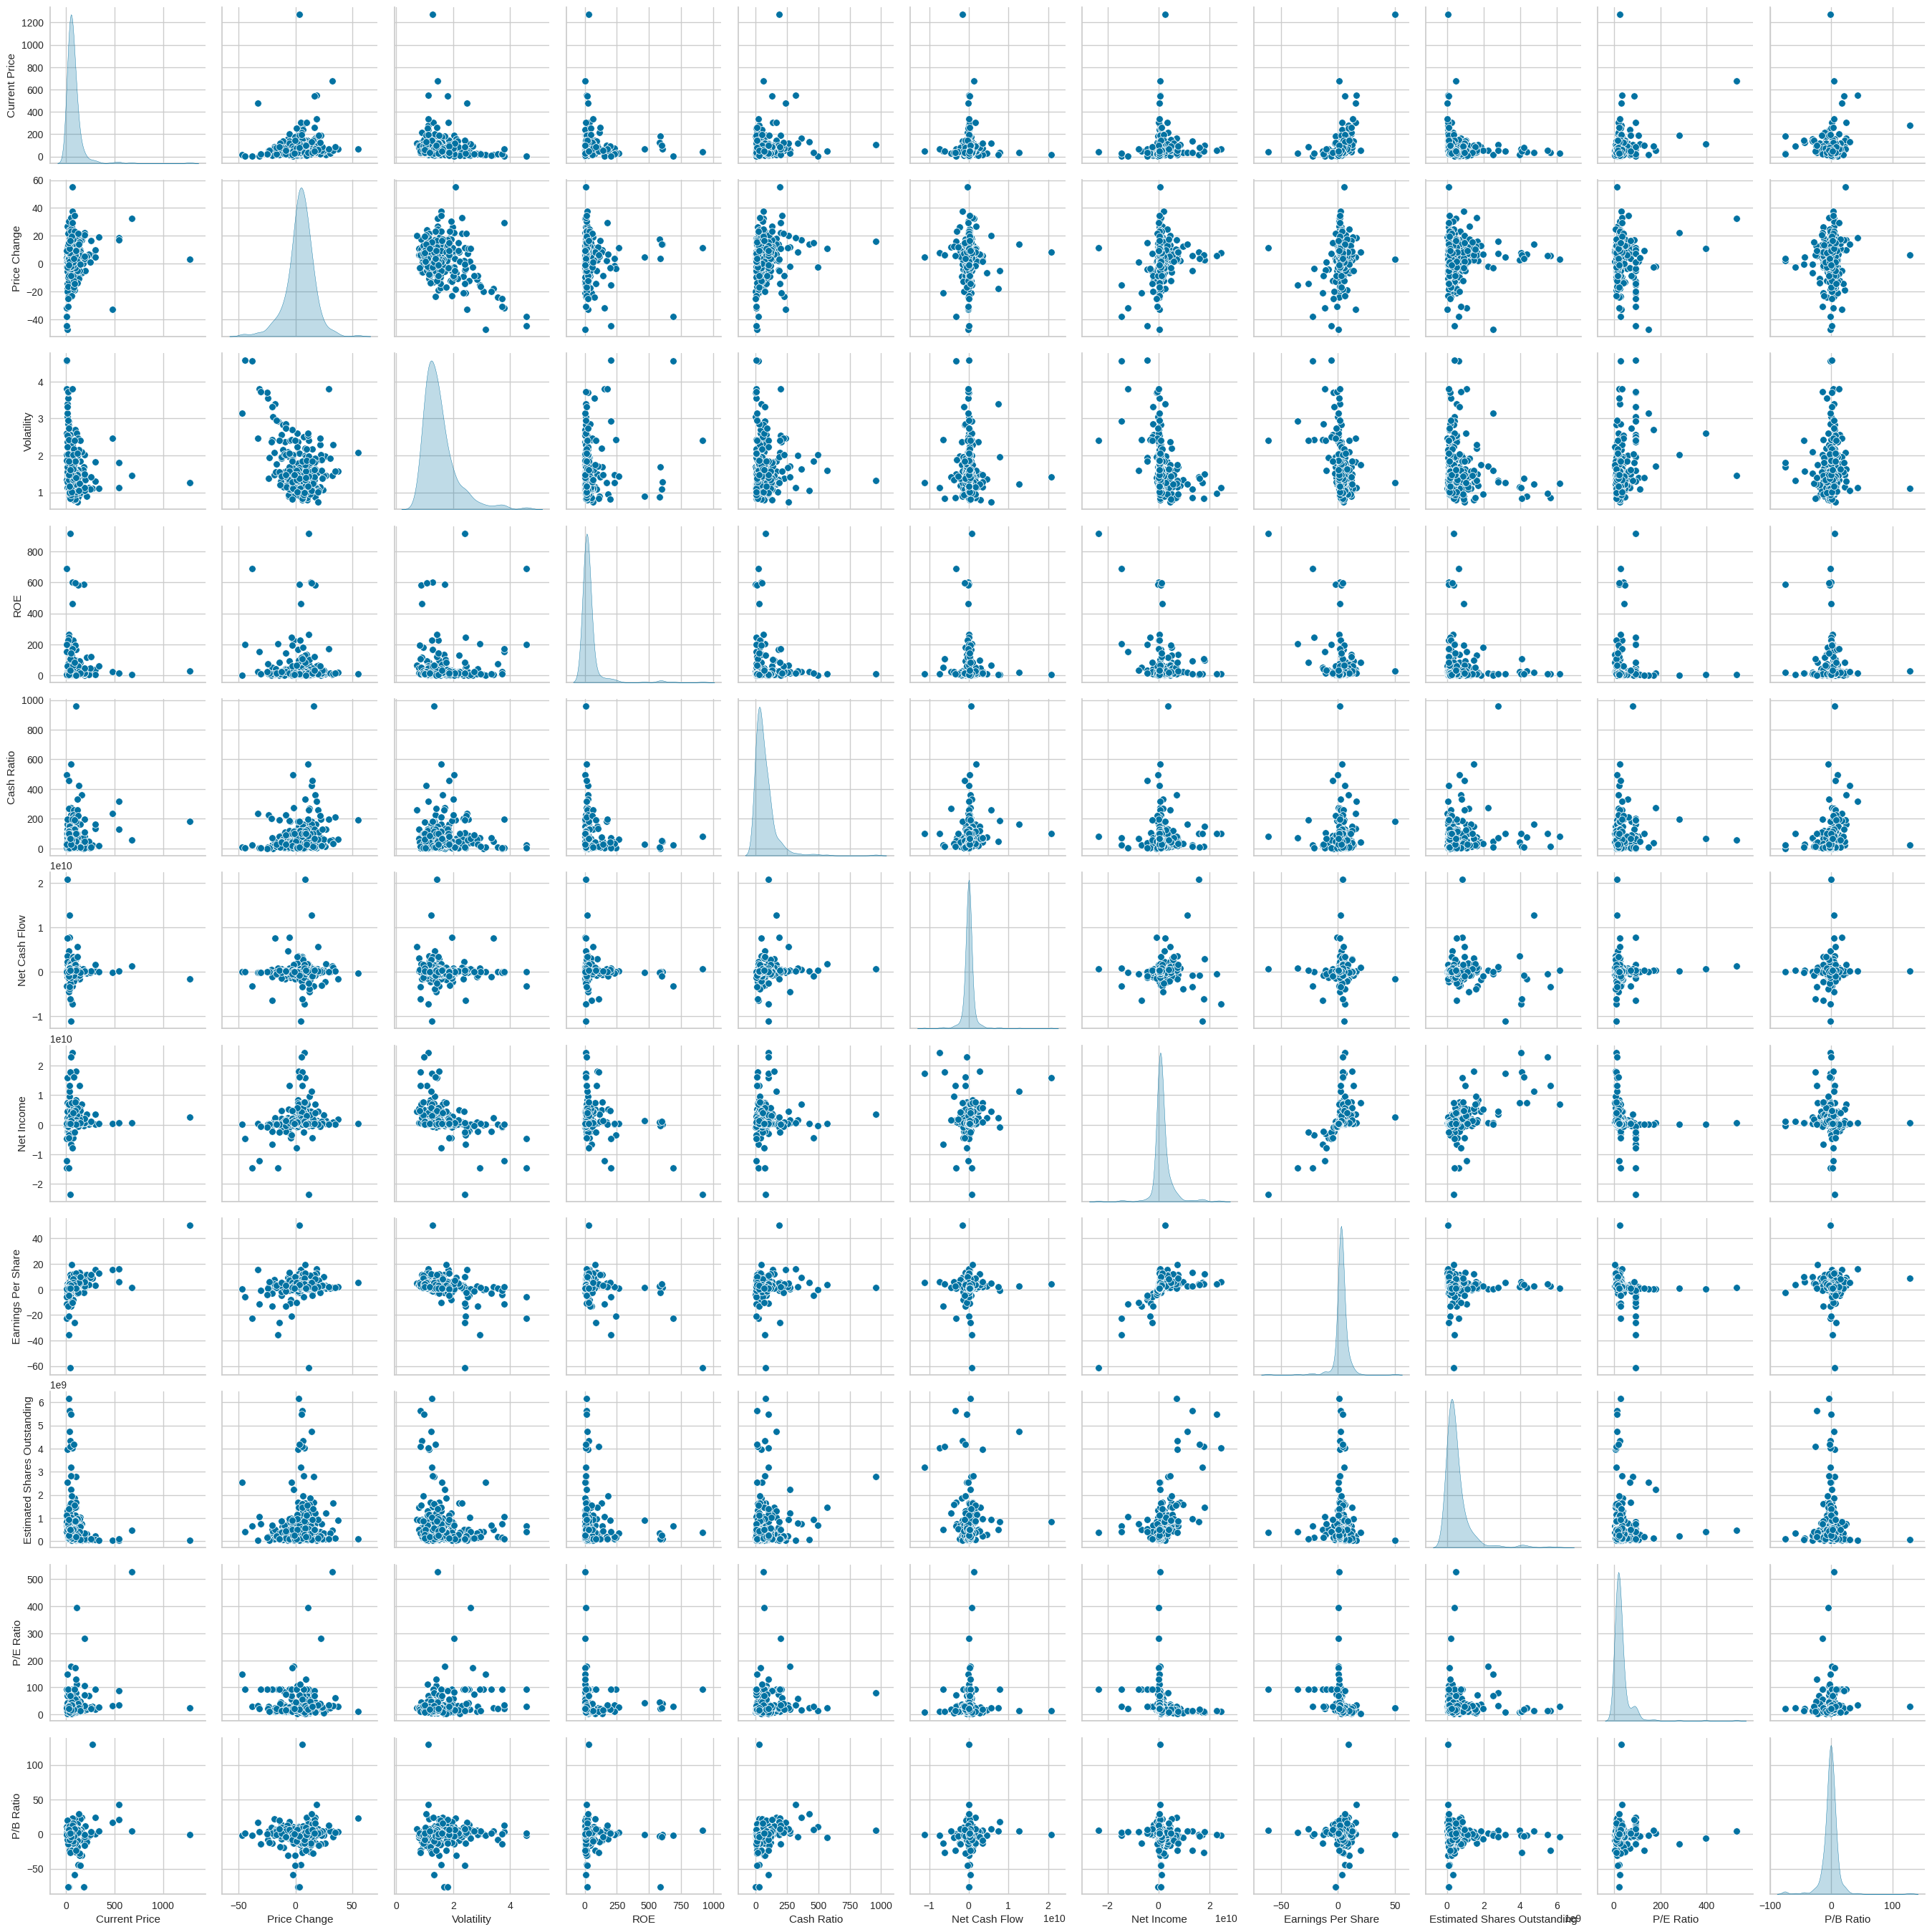

In [ ]:
sns.pairplot(data=df[num_col], diag_kind="kde")
plt.show()

Observations:

- Many heavy-tailed distributions
- Sector structure is visible, but no single driver dominates.
- Price Change ~≈ normal, centered near zero.
- Volatility vs Price Change = wider fan.
- EPS ↔ Net Income: strong positive relation.
- Net Income ↔ Net Cash Flow: moderate positive, with noise.
- Price vs EPS/NI: weak-to-modest positive trend.


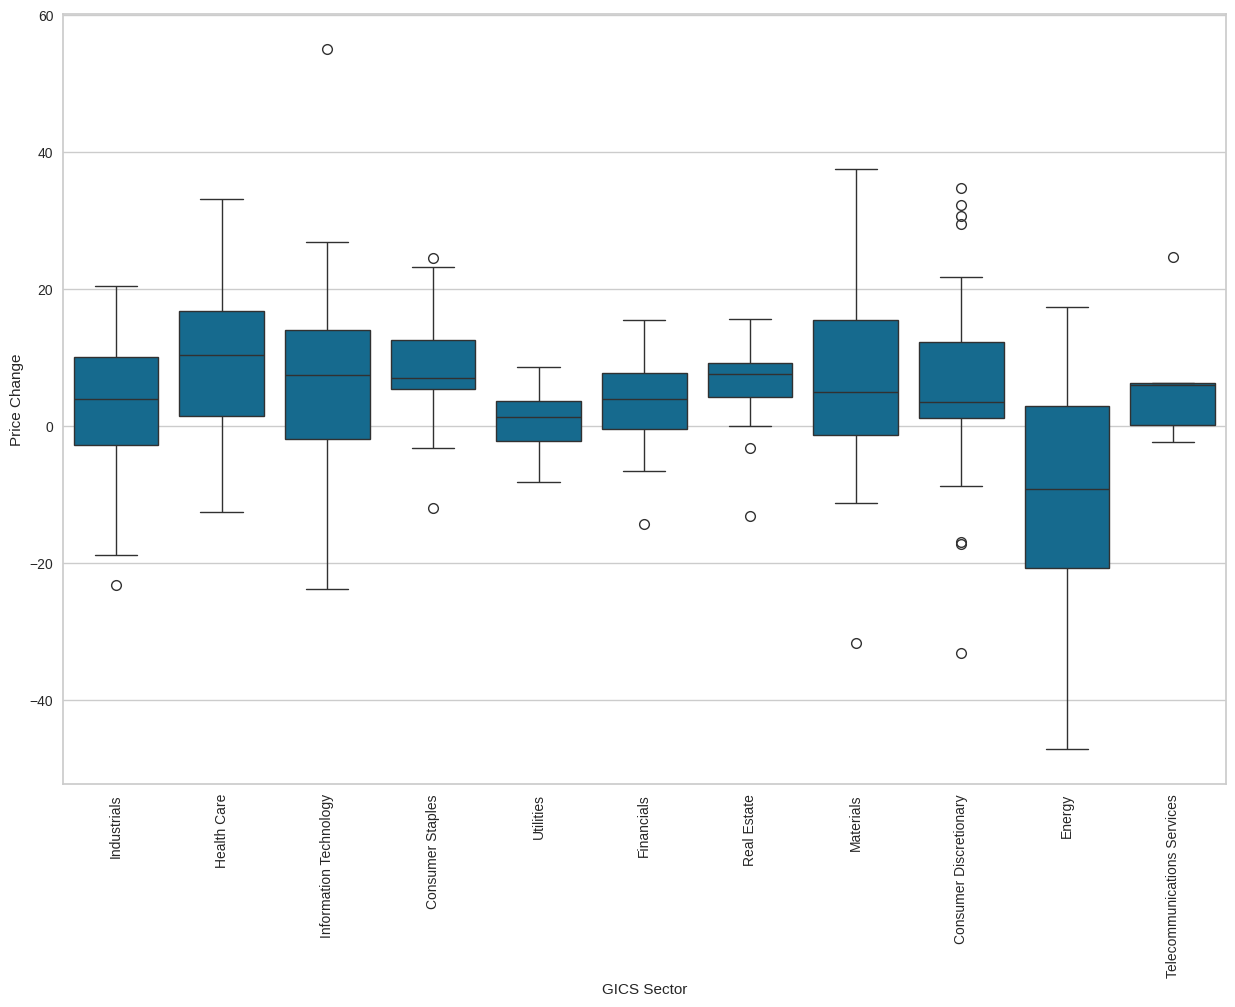

In [ ]:
#Checking GICS Sector vs Price Change
plt.figure(figsize=(15,10))
sns.boxplot(x='GICS Sector',y='Price Change',data=df)
plt.xticks(rotation=90)
plt.show()

Observations:

Leaders (higher medians): Health Care is the standout (highest central line). Materials and Consumer Discretionary also sit on the higher side.

Middle pack: Real Estate, Financials, IT, Industrials hover near small positives (some wide IQRs).

Laggards: Energy shows the lowest median and the widest spread (heavy downside outliers). Utilities and Telecom look relatively low/steady.

Dispersion: Energy, Materials, and Consumer Discretionary have large IQRs and many outliers → more volatile sector moves.

Skew: Several sectors are right-skewed (longer positive whiskers) but Energy is left-skewed (deep negative tail).

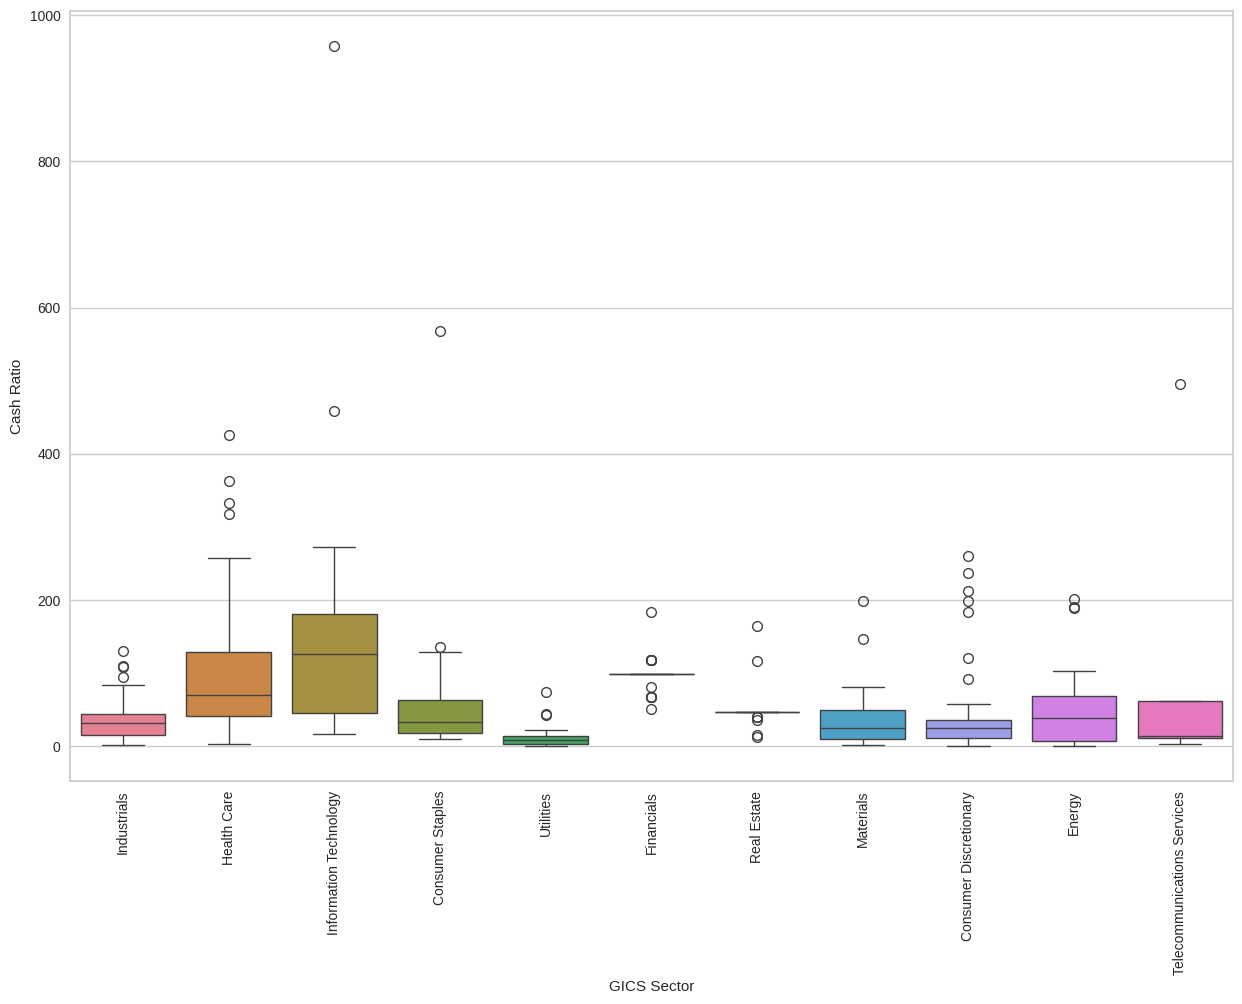

In [ ]:
# #Checking GICS Sector vs Cash Ratio
plt.figure(figsize=(15,10))
sns.boxplot(x='GICS Sector',y='Cash Ratio',data=df,hue= 'GICS Sector')
plt.xticks(rotation=90)
plt.show()

Observations:

- Higher typical liquidity (medians): Information Technology and Health Care sit highest, with wide IQRs and many large outliers.

- Outliers: Several sectors show extreme cash ratios (e.g., IT, Health Care, Telecom), creating long upper tails.

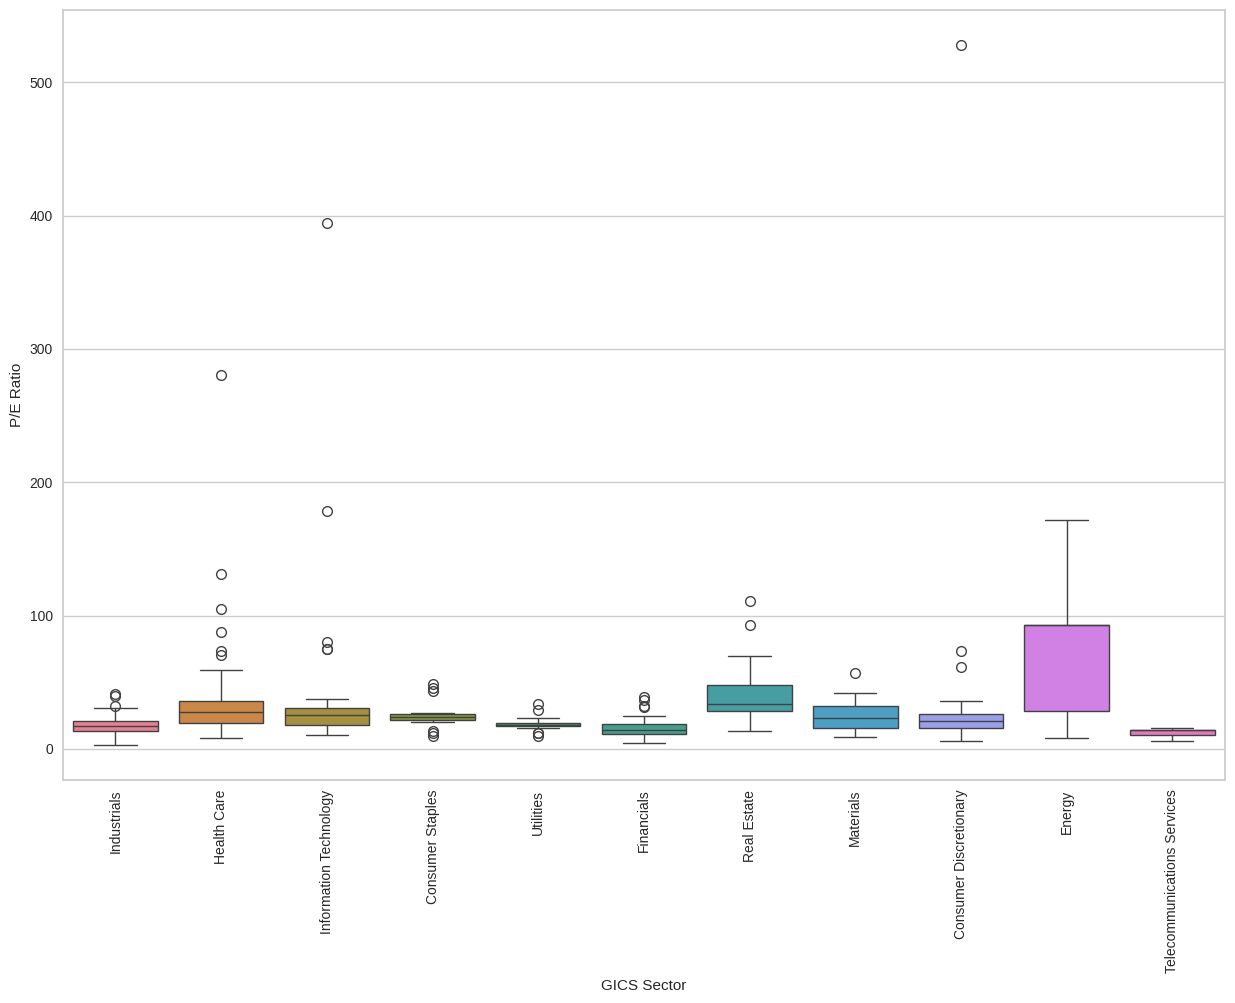

In [ ]:
 #Checking GICS Sector vs P/E Ratio
 plt.figure(figsize=(15,10))
 sns.boxplot(x='GICS Sector',y='P/E Ratio',data=df,hue= 'GICS Sector')
 plt.xticks(rotation=90)
 plt.show()

Observations:

- Spread & outliers: Energy has the widest dispersion. Health Care, Information Technoligt and Real Estate also show very long right tails.

### Questions

**Questions**:

1. What does the distribution of stock prices look like?
2. The stocks of which economic sector have seen the maximum price increase on average?
3. How are the different variables correlated with each other?
4. Cash ratio provides a measure of a company's ability to cover its short-term obligations using only cash and cash equivalents. How does the average cash ratio vary across economic sectors?
5. P/E ratios can help determine the relative value of a company's shares as they signify the amount of money an investor is willing to invest in a single share of a company per dollar of its earnings. How does the P/E ratio vary, on average, across economic sectors?

**1. What does the distribution of stock prices look like?**

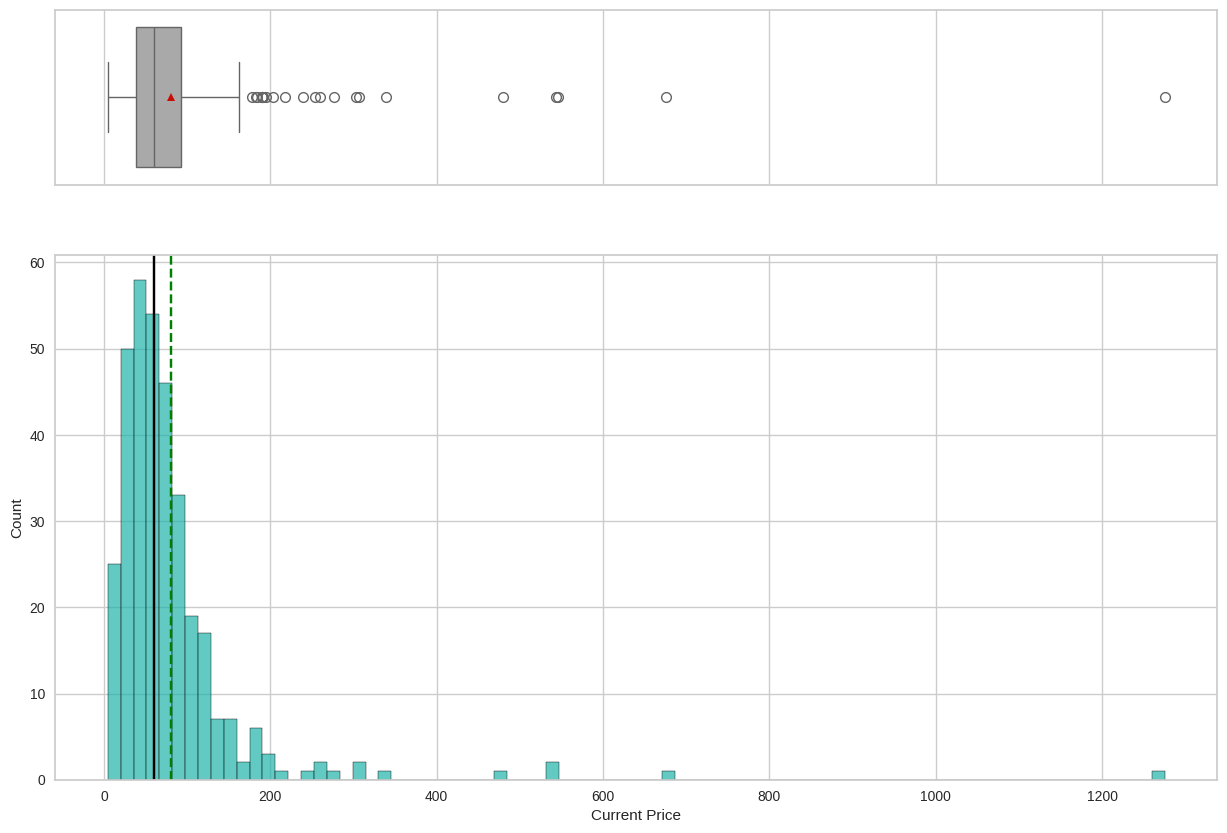

In [ ]:
# distribution of stock prices
histogram_boxplot(df, 'Current Price')

Observations:
- Strong right-skew. Most stocks cluster between ~ 20– 120; the dashed line (median) is ~ 59.7.Mean≈ 80.9 > median → tail pulls right.

**2. The stocks of which economic sector have seen the maximum price increase on average?**

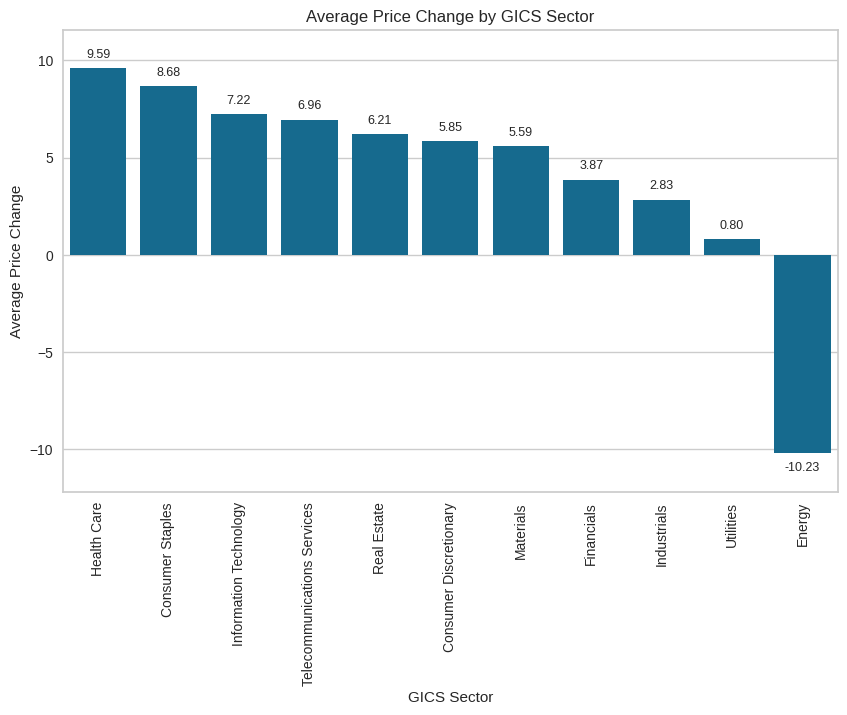

In [ ]:
# prep
s = (df.groupby('GICS Sector')['Price Change']
       .mean()
       .sort_values(ascending=False))

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(x=s.index, y=s.values, ax=ax)

ax.set_xlabel('GICS Sector')
ax.set_ylabel('Average Price Change')
ax.set_title('Average Price Change by GICS Sector')
plt.xticks(rotation=90)

# add labels
ymin, ymax = s.min(), s.max()
yrange = ymax - ymin if ymax != ymin else 1.0
pad = 0.02 * yrange  # a small offset so labels don’t sit on the bar edge

for i, v in enumerate(s.values):
    ax.text(
        i,
        v + (pad if v >= 0 else -pad),
        f'{v:.2f}',
        ha='center',
        va='bottom' if v >= 0 else 'top',
        fontsize=9
    )

ax.margins(y=0.1)  # a little headroom for the labels
plt.show()

Observations:

- Health Care has the highest average price increase, at ≈ +9.59 (based on Price Change grouped by GICS Sector).

**3. How are the different variables correlated with each other?**

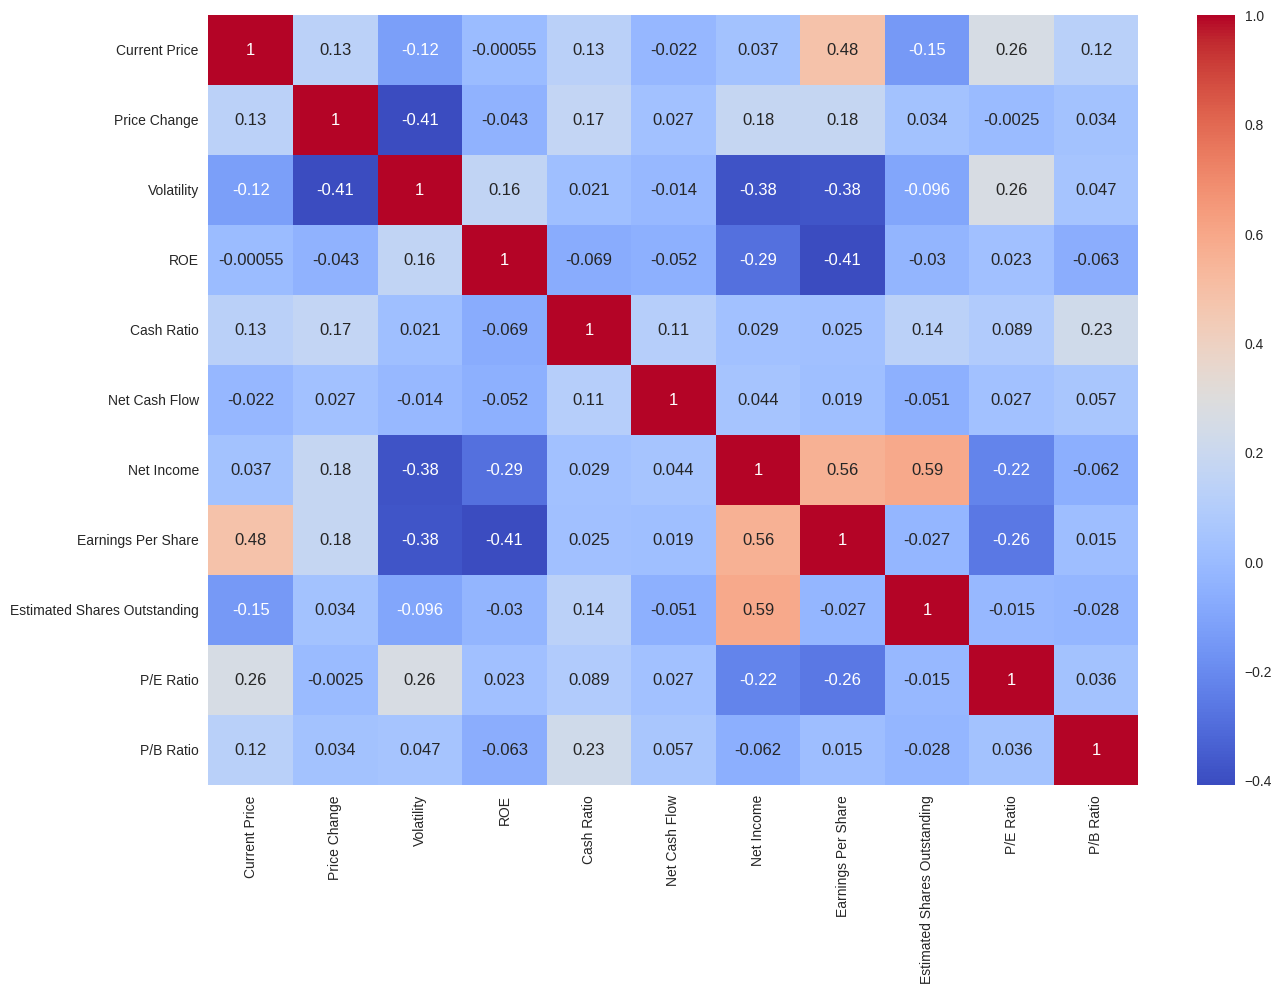

In [ ]:
#correlation for numeric variable
num_col=df.select_dtypes(include=['int64','float64']).columns

#heatmap
plt.figure(figsize=(15,10))
sns.heatmap(df[num_col].corr(),annot=True,cmap='coolwarm')
plt.show()





Observations:

**Moderate/strong relationships**

Net Income ↔ Estimated Shares Outstanding: ρ ≈ 0.59 ( + ) — bigger companies earn more in absolute dollars.

Net Income ↔ EPS: ρ ≈ 0.56 ( + ) — expected, since EPS is income scaled by shares.

Current Price ↔ EPS: ρ ≈ 0.48 ( + ) — higher EPS tends to be priced higher.

**Volatility cuts against fundamentals**

Volatility ↔ Net Income: ρ ≈ −0.38 and Volatility ↔ EPS: ρ ≈ −0.38 — more profitable firms are typically less volatile.

Price Change ↔ Volatility: ρ ≈ −0.41 — within this snapshot, higher-vol names skew to weaker returns.

**Valuation ratios are noisy**

P/E ↔ ROE: ρ ≈ 0.26 ( + ) — better profitability tends to command higher P/E.

P/E ↔ EPS: ρ ≈ −0.26 and P/E ↔ Net Income: ρ ≈ −0.22 — the usual instability when EPS is near/≤0.

P/B has only small links; the largest is P/B ↔ Cash Ratio: ρ ≈ 0.23.


Current Price ↔ Shares Outstanding: ρ ≈ −0.15 — more shares often come with lower per-share price (mechanical).


**4. Cash ratio provides a measure of a company's ability to cover its short-term obligations using only cash and cash equivalents. How does the average cash ratio vary across economic sectors?**

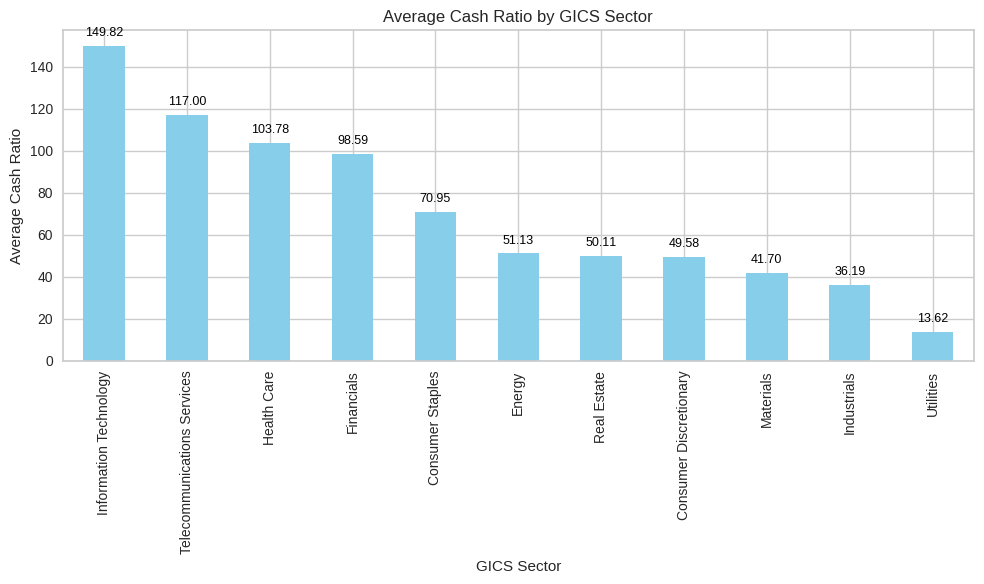

In [ ]:
import matplotlib.pyplot as plt

# Average cash ratio by sector
cash_ratio_by_sector = df.groupby('GICS Sector')['Cash Ratio'].mean().sort_values(ascending=False)

# Plot
ax = cash_ratio_by_sector.plot(kind='bar', figsize=(10, 6), color='skyblue')
plt.title('Average Cash Ratio by GICS Sector')
plt.xlabel('GICS Sector')
plt.ylabel('Average Cash Ratio')

# Add labels to each bar
for patch in ax.patches:
    height = patch.get_height()
    ax.annotate(f'{height:.2f}',
                xy=(patch.get_x() + patch.get_width() / 2, height),
                xytext=(0, 5),
                textcoords='offset points',
                ha='center', va='bottom',
                fontsize=9, color='black')

plt.tight_layout()
plt.show()

Observations:

-  Information Technology (149.82): Tops the chart

- Telecommunications Services (117.00) and Health Care (103.78): Also maintain high cash reserves.

Moderate Liquidity Sector

- Financials (98.59)

- Consumer Staples (70.95)


 Low Liquidity Sectors

 - Energy (51.13), Real Estate (50.11), and Consumer Discretionary (49.58)

- Materials (41.70) and Industrials (36.19)

- Utilities (13.62)






**5. P/E ratios can help determine the relative value of a company's shares as they signify the amount of money an investor is willing to invest in a single share of a company per dollar of its earnings. How does the P/E ratio vary, on average, across economic sectors?**

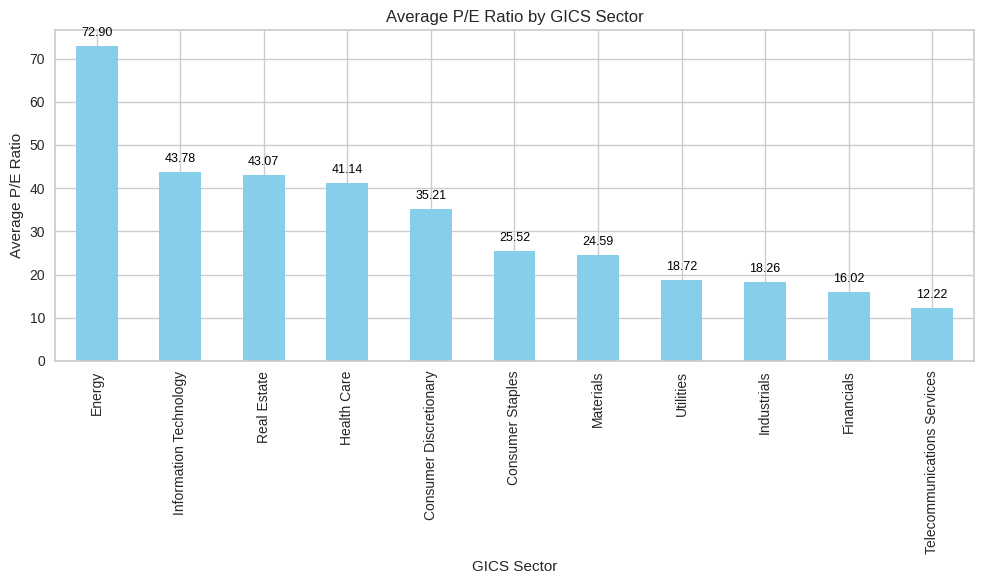

In [ ]:

# Average  P/E ratio by sector
pe_ratio_by_sector = df.groupby('GICS Sector')['P/E Ratio'].mean().sort_values(ascending=False)

# Plot
ax = pe_ratio_by_sector.plot(kind='bar', figsize=(10, 6), color='skyblue')
plt.title('Average P/E Ratio by GICS Sector')
plt.xlabel('GICS Sector')
plt.ylabel('Average P/E Ratio')

# Add labels to each bar
for patch in ax.patches:
    height = patch.get_height()
    ax.annotate(f'{height:.2f}',
                xy=(patch.get_x() + patch.get_width() / 2, height),
                xytext=(0, 5),
                textcoords='offset points',
                ha='center', va='bottom',
                fontsize=9, color='black')

plt.tight_layout()
plt.show()

Observations:

- Highest: Energy with an average P/E ≈ 72.90

- Lowest: Telecommunications Services with an average P/E ≈ 12.22

- Sectors analyzed: 11

### Key insights from EDA

Sector & Sub-Industry Composition

- GICS Sector Spread: Dominated by Industrials (15.6%) and Financials (14.4%). Telecom Services is underrepresented (1.5%), which may affect clustering granularity.
- Top Sub-Industries: Oil & Gas Exploration, REITs, and Industrial Conglomerates lead the count—suggesting macroeconomic exposure and thematic clustering potential.

Price & Performance Metrics

- Current Price: Right-skewed with heavy concentration at lower values. Outliers suggest high-priced stocks that may distort mean-based metrics.
- Price Change: Near-normal distribution centered around zero. Sector-wise boxplots reveal that Energy and Telecom show wider variability, while Utilities and Staples are more stable.

Volatility & Liquidity

- Volatility: Most values fall between 1.0 and 2.0, with a peak near 1.0. Outliers exist but are not dominant—ideal for clustering stability.
- Cash Ratio: Skewed right; Information Technology shows the highest median liquidity, while Utilities lag. Sector-wise boxplots highlight liquidity asymmetry across industries.

Profitability & Valuation

- ROE & Net Income: Both are right-skewed with heavy tails. Most firms cluster near zero, suggesting low profitability or early-stage status.
- EPS: Mirrors net income—concentrated near zero with outliers on both ends. Reinforces the need for transformation or segmentation.
- P/E Ratio: Skewed toward lower values with high outliers. Indicates a mix of undervalued and speculative entities—ideal for valuation-based screening.

Cash Flow & Capital Structure

- Net Cash Flow: Extremely concentrated around zero. Sparse deviations suggest cyclical or normalized cash behavior.
- Estimated Shares Outstanding: Included in correlation matrix—useful for scaling metrics like EPS and ROE.




## Data Preprocessing

- Duplicate value check
- Missing value treatment
- Outlier check
- Feature engineering (if needed)
- Any other preprocessing steps (if needed)

Duplicate value check

In [ ]:
df.duplicated().sum()

np.int64(0)

Observations: Data without duplicates

Missing value treatment

In [ ]:
df.isnull().sum()

,0
Ticker Symbol,0
Security,0
GICS Sector,0
GICS Sub Industry,0
Current Price,0
Price Change,0
Volatility,0
ROE,0
Cash Ratio,0
Net Cash Flow,0


Observations: Dataset without missing values

Outlier check

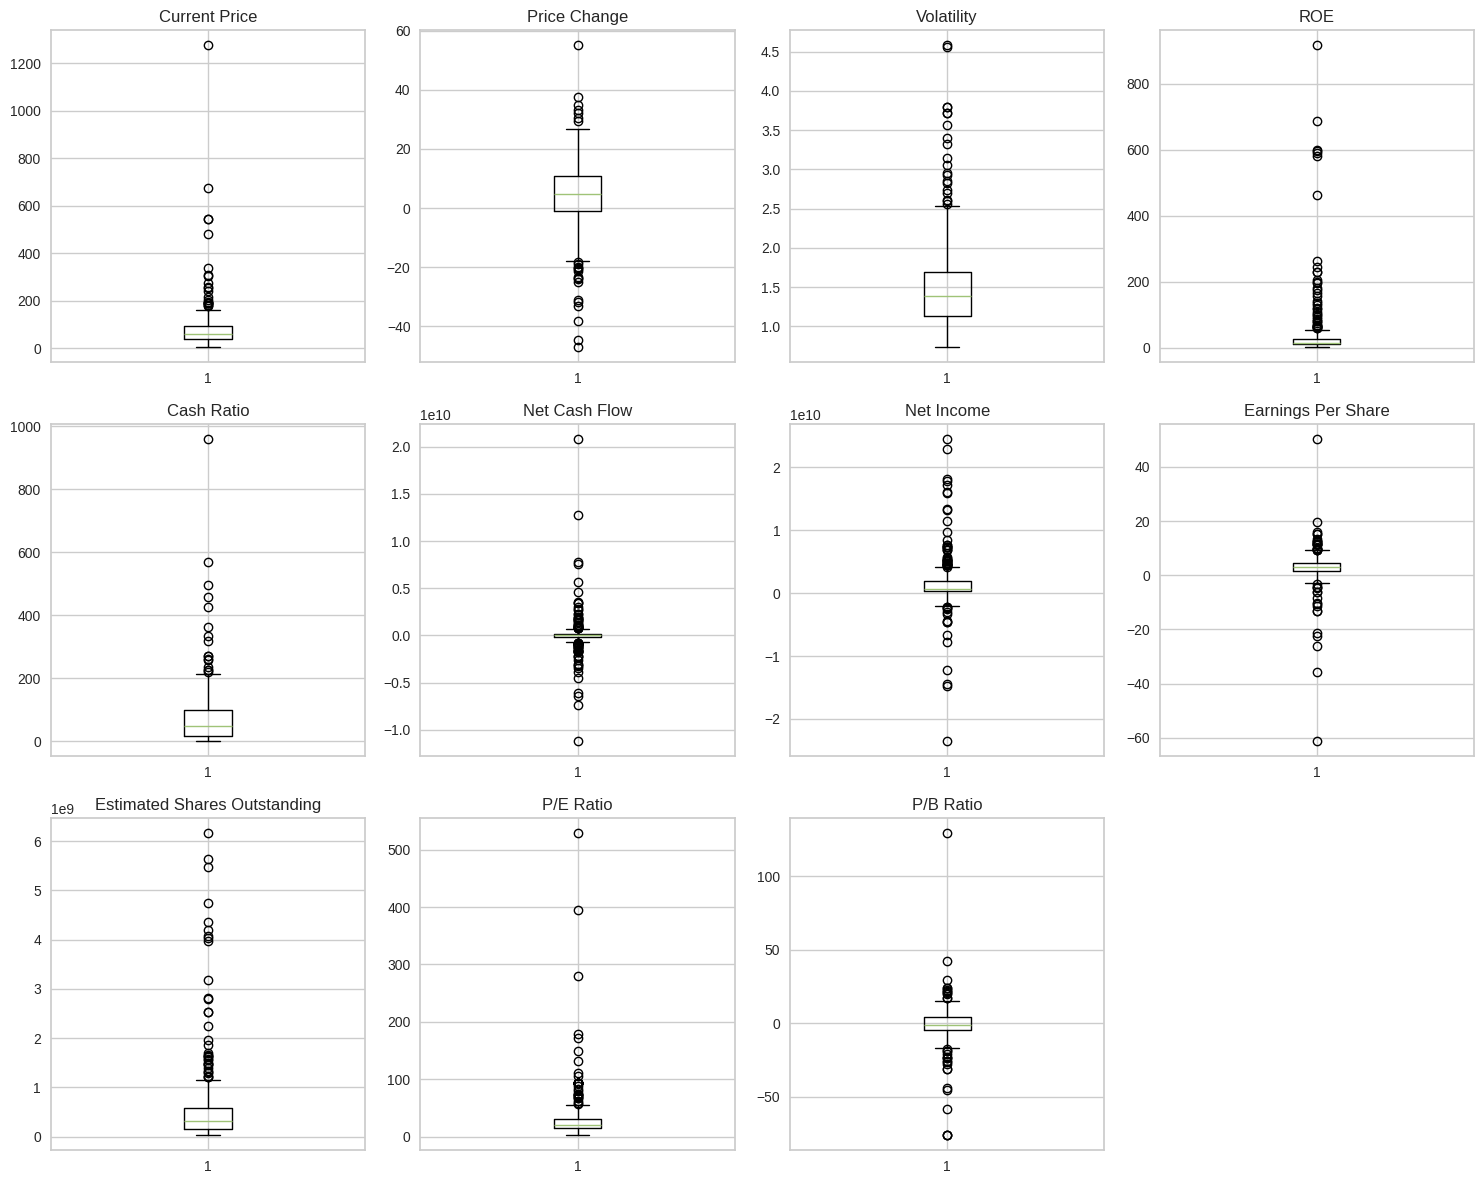

In [ ]:
# Outlier check
plt.figure(figsize=(15, 12))

numeric_columns = df.select_dtypes(include=np.number).columns.tolist()

for i, variable in enumerate(numeric_columns):
    plt.subplot(3, 4, i + 1)
    plt.boxplot(df[variable], whis=1.5)
    plt.tight_layout()
    plt.title(variable)

plt.show()

Observations:

There are a lot of outliers in the data. However, we will not treat them as they are proper values.

### Scaling

In [ ]:
scaler = StandardScaler() #We need to scale the data before do the clustering
subset = df[numeric_columns].copy()
subset_scaled = scaler.fit_transform(subset)

In [ ]:
# creating a dataframe of the scaled data
subset_scaled_df = pd.DataFrame(subset_scaled, columns=subset.columns)

In [ ]:
#import numpy as np, random
#np.random.seed(42); random.seed(42)

In [ ]:
#df.sample(n=10, random_state=1)



## K-means Clustering

### 5.1 K-means Clustering Checking Elbow Plot

In [ ]:
k_means_df = subset_scaled_df.copy()

Number of Clusters: 1 	Average Distortion: 2.5425069919221697
Number of Clusters: 2 	Average Distortion: 2.3862098789299604
Number of Clusters: 3 	Average Distortion: 2.33620927590848
Number of Clusters: 4 	Average Distortion: 2.219050563833442
Number of Clusters: 5 	Average Distortion: 2.133404401901685
Number of Clusters: 6 	Average Distortion: 2.081503686093715
Number of Clusters: 7 	Average Distortion: 2.0045413402786814
Number of Clusters: 8 	Average Distortion: 1.9864237824874411
Number of Clusters: 9 	Average Distortion: 1.956222103389025
Number of Clusters: 10 	Average Distortion: 1.9360473996664198
Number of Clusters: 11 	Average Distortion: 1.8615942883461607
Number of Clusters: 12 	Average Distortion: 1.8219574388532505
Number of Clusters: 13 	Average Distortion: 1.7936924742607907
Number of Clusters: 14 	Average Distortion: 1.7567842179093438


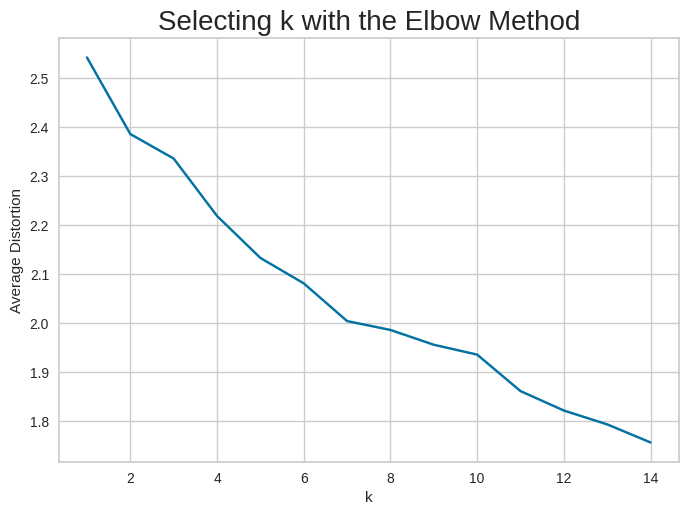

In [ ]:
clusters = range(1, 15)
meanDistortions = []

for k in clusters:
    model = KMeans(n_clusters=k, random_state=1)
    model.fit(subset_scaled_df)
    prediction = model.predict(k_means_df)
    distortion = (
        sum(np.min(cdist(k_means_df, model.cluster_centers_, "euclidean"), axis=1))
        / k_means_df.shape[0]
    )

    meanDistortions.append(distortion)

    print("Number of Clusters:", k, "\tAverage Distortion:", distortion)

plt.plot(clusters, meanDistortions, "bx-")
plt.xlabel("k")
plt.ylabel("Average Distortion")
plt.title("Selecting k with the Elbow Method", fontsize=20)
plt.show()

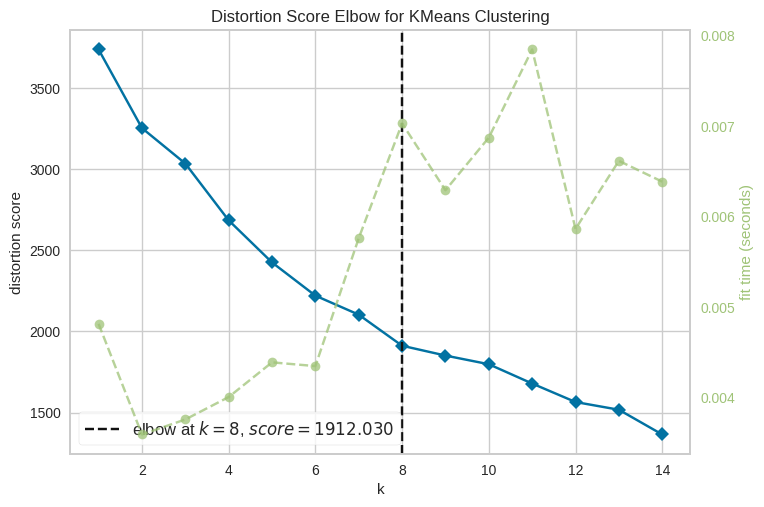

<Axes: title={'center': 'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [ ]:
model = KMeans(random_state=1)
visualizer = KElbowVisualizer(model, k=(1, 15), timings=True)
visualizer.fit(k_means_df)  # fit the data to the visualizer
visualizer.show()  # finalize and render figure


### 5.2 Let's check the silhouette scores

For n_clusters = 2, the silhouette score is 0.45335782729503565)
For n_clusters = 3, the silhouette score is 0.40374060030338865)
For n_clusters = 4, the silhouette score is 0.4246430808437099)
For n_clusters = 5, the silhouette score is 0.4381539778147092)
For n_clusters = 6, the silhouette score is 0.40869599703024256)
For n_clusters = 7, the silhouette score is 0.1207450219233897)
For n_clusters = 8, the silhouette score is 0.3693991650696542)
For n_clusters = 9, the silhouette score is 0.35185096182499204)
For n_clusters = 10, the silhouette score is 0.32950073703610283)
For n_clusters = 11, the silhouette score is 0.1486586842527321)
For n_clusters = 12, the silhouette score is 0.15784241071085106)
For n_clusters = 13, the silhouette score is 0.15646997458716602)
For n_clusters = 14, the silhouette score is 0.16253506827999134)


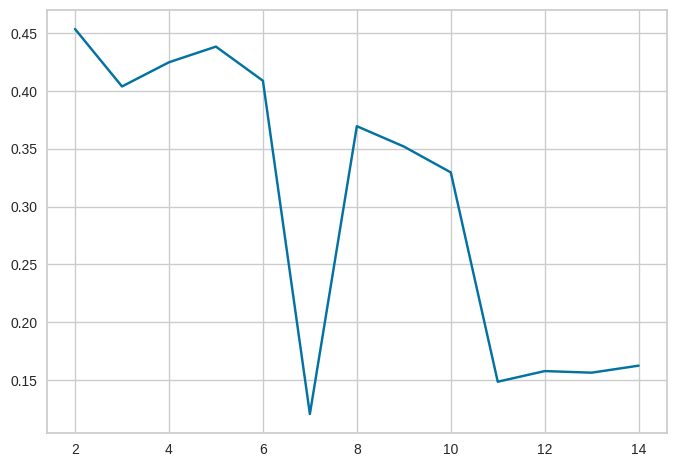

In [ ]:
sil_score = []
cluster_list = range(2, 15)
for n_clusters in cluster_list:
    clusterer = KMeans(n_clusters=n_clusters, random_state=1)
    preds = clusterer.fit_predict((subset_scaled_df))
    score = silhouette_score(k_means_df, preds)
    sil_score.append(score)
    print("For n_clusters = {}, the silhouette score is {})".format(n_clusters, score))

plt.plot(cluster_list, sil_score)
plt.show()

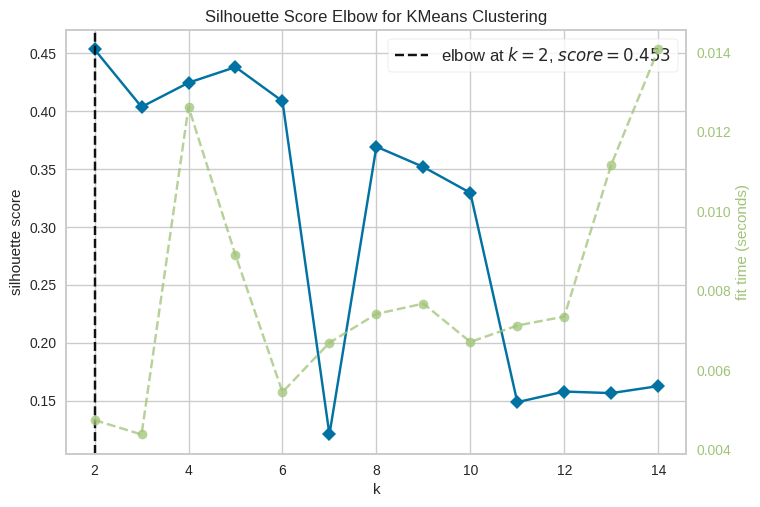

<Axes: title={'center': 'Silhouette Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='silhouette score'>

In [ ]:
model = KMeans(random_state=1)
visualizer = KElbowVisualizer(model, k=(2, 15), metric="silhouette", timings=True)
visualizer.fit(k_means_df)  # fit the data to the visualizer
visualizer.show()  # finalize and render figure

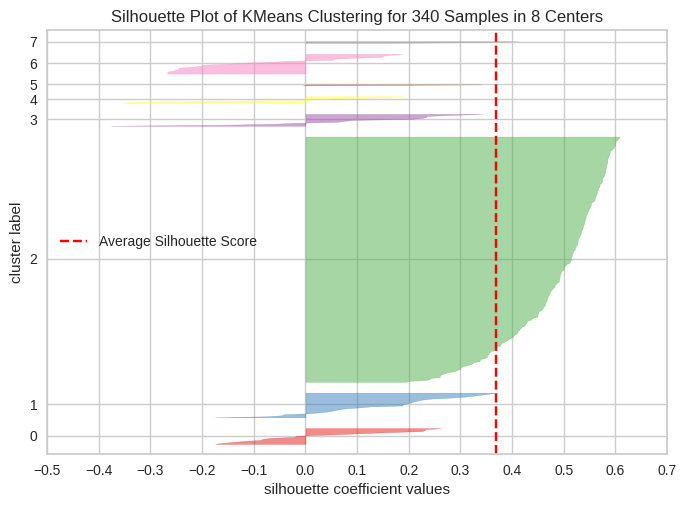

<Axes: title={'center': 'Silhouette Plot of KMeans Clustering for 340 Samples in 8 Centers'}, xlabel='silhouette coefficient values', ylabel='cluster label'>

In [ ]:
# finding optimal no. of clusters with silhouette coefficients
visualizer = SilhouetteVisualizer(KMeans(8, random_state=1))
visualizer.fit(k_means_df)
visualizer.show()

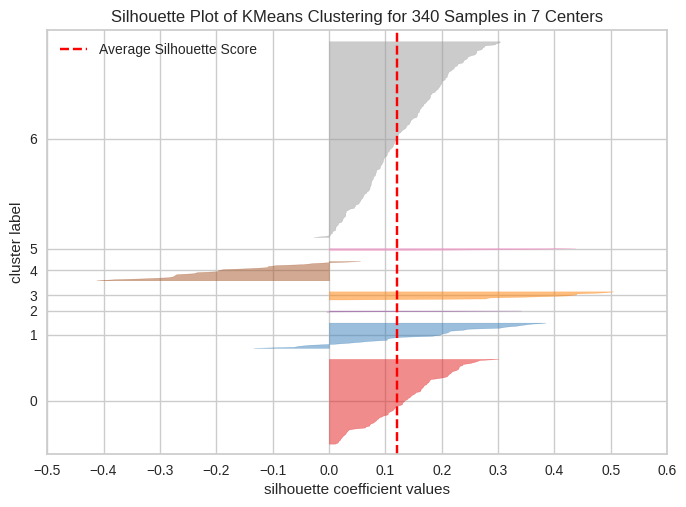

<Axes: title={'center': 'Silhouette Plot of KMeans Clustering for 340 Samples in 7 Centers'}, xlabel='silhouette coefficient values', ylabel='cluster label'>

In [ ]:
# finding optimal no. of clusters with silhouette coefficients
visualizer = SilhouetteVisualizer(KMeans(7, random_state=1))
visualizer.fit(k_means_df)
visualizer.show()

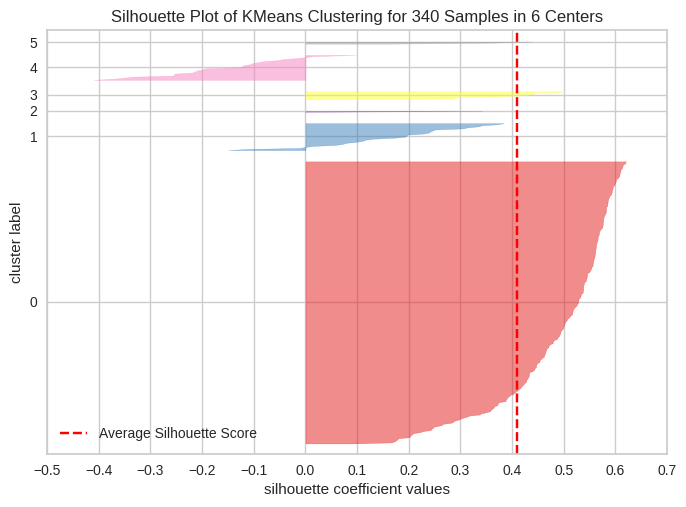

<Axes: title={'center': 'Silhouette Plot of KMeans Clustering for 340 Samples in 6 Centers'}, xlabel='silhouette coefficient values', ylabel='cluster label'>

In [ ]:
# finding optimal no. of clusters with silhouette coefficients
visualizer = SilhouetteVisualizer(KMeans(6, random_state=1))
visualizer.fit(k_means_df)
visualizer.show()

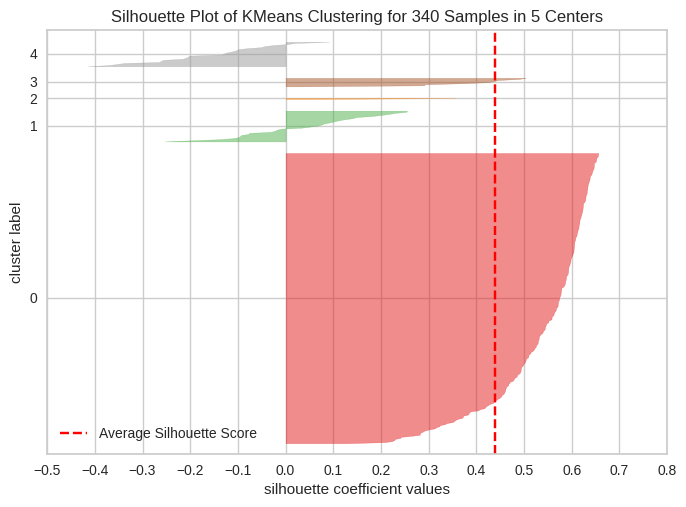

<Axes: title={'center': 'Silhouette Plot of KMeans Clustering for 340 Samples in 5 Centers'}, xlabel='silhouette coefficient values', ylabel='cluster label'>

In [ ]:
# finding optimal no. of clusters with silhouette coefficients
visualizer = SilhouetteVisualizer(KMeans(5, random_state=1))
visualizer.fit(k_means_df)
visualizer.show()

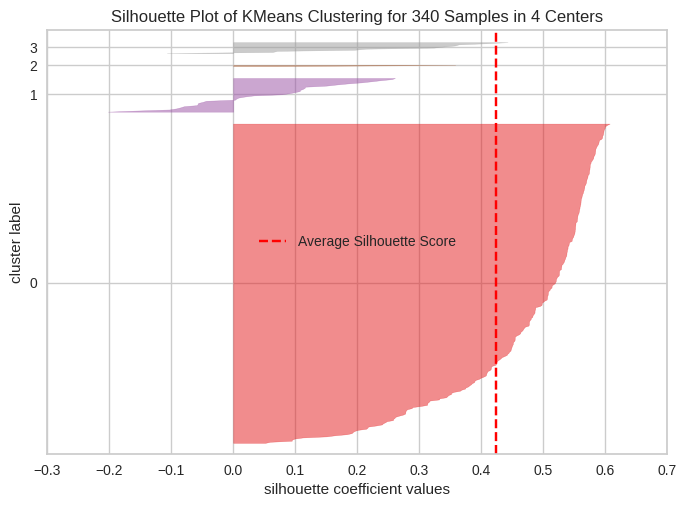

<Axes: title={'center': 'Silhouette Plot of KMeans Clustering for 340 Samples in 4 Centers'}, xlabel='silhouette coefficient values', ylabel='cluster label'>

In [ ]:
# finding optimal no. of clusters with silhouette coefficients
visualizer = SilhouetteVisualizer(KMeans(4, random_state=1))
visualizer.fit(k_means_df)
visualizer.show()

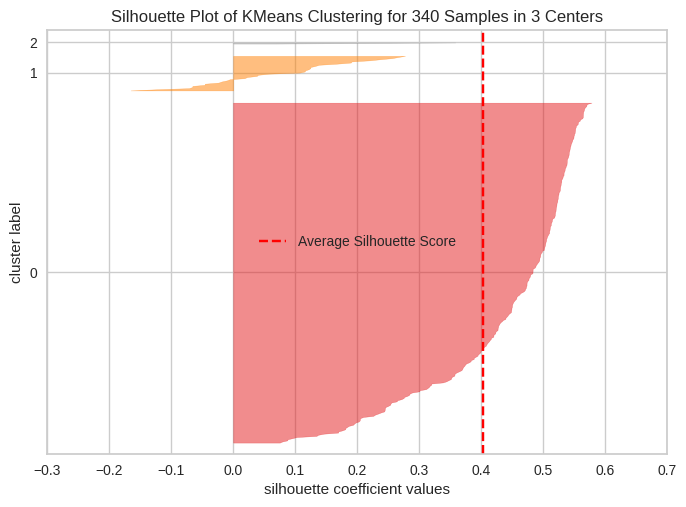

<Axes: title={'center': 'Silhouette Plot of KMeans Clustering for 340 Samples in 3 Centers'}, xlabel='silhouette coefficient values', ylabel='cluster label'>

In [ ]:
# finding optimal no. of clusters with silhouette coefficients
visualizer = SilhouetteVisualizer(KMeans(3, random_state=1))
visualizer.fit(k_means_df)
visualizer.show()

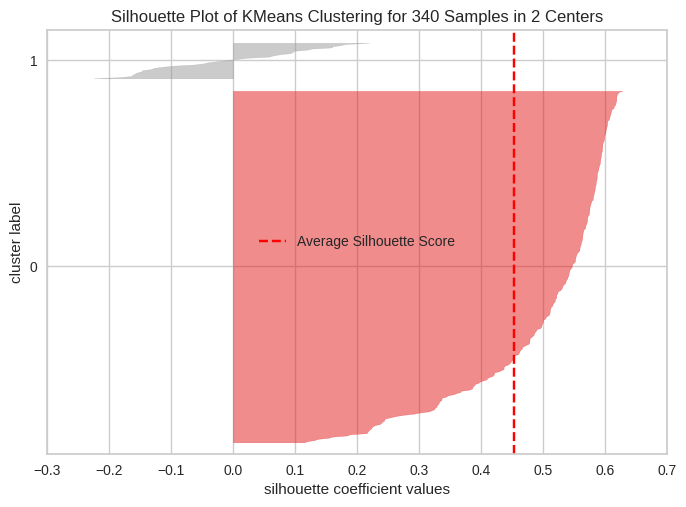

<Axes: title={'center': 'Silhouette Plot of KMeans Clustering for 340 Samples in 2 Centers'}, xlabel='silhouette coefficient values', ylabel='cluster label'>

In [ ]:
# finding optimal no. of clusters with silhouette coefficients
visualizer = SilhouetteVisualizer(KMeans(2, random_state=1))
visualizer.fit(k_means_df)
visualizer.show()

Observations:

- k=2 is the mathematical max but too coarse for profiling.

- k=4–5 gives the best balance of separation, stability, and interpretability.

- k=7 and, more generally, k≥8 for this dataset.


-**K = 4 is the strikes the best balance for the data provided**
  
  It offers:
  - Strong average silhouette score
  - Visually balanced clusters
  - Minimal overlap and fragmentation




### 5.3 Creating Final Model

In [ ]:
kmeans = KMeans(n_clusters=4 , random_state=1)  ## Complete the code to choose the number of clusters
kmeans.fit(k_means_df)

KMeans(n_clusters=4, random_state=1)

In [ ]:
# creating a copy of the original data
df1 = df.copy()

# adding kmeans cluster labels to the original and scaled dataframes
k_means_df["KM_segments"] = kmeans.labels_
df1["KM_segments"] = kmeans.labels_

### 5.4 Cluster Profiling

In [ ]:
km_cluster_profile = df1.groupby("KM_segments").mean(numeric_only=True)


In [ ]:
km_cluster_profile["count_in_each_segment"] = (
    df1.groupby("KM_segments")["Security"].count().values
)

In [ ]:
km_cluster_profile.style.highlight_max(color="green", axis=0)

,Current Price,Price Change,Volatility,ROE,Cash Ratio,Net Cash Flow,Net Income,Earnings Per Share,Estimated Shares Outstanding,P/E Ratio,P/B Ratio,count_in_each_segment
KM_segments,,,,,,,,,,,,
0,84.176635,5.702764,1.396635,33.962712,69.972881,90456322.033898,1517730698.305085,3.890390,444140390.526542,24.645180,-2.015145,295
1,64.263438,-10.382780,2.732033,46.812500,69.656250,205568000.000000,-2018462218.750000,-5.177187,526311835.891875,110.425211,1.787692,32
2,24.485001,-13.351992,3.482611,802.000000,51.000000,-1292500000.000000,-19106500000.000000,-41.815000,519573983.250000,60.748608,1.565141,2
3,50.517273,5.747586,1.130399,31.090909,75.909091,-1072272727.272727,14833090909.090910,4.154545,4298826628.727273,14.803577,-4.552119,11


In [ ]:
## Complete the code to print the companies in each cluster
for cl in df1["KM_segments"].unique():
    print("In cluster {}, the following companies are present:".format(cl))
    print(df1[df1["KM_segments"] == cl]["Security"].unique())
    print()

In cluster 0, the following companies are present:
['American Airlines Group' 'AbbVie' 'Abbott Laboratories'
 'Adobe Systems Inc' 'Archer-Daniels-Midland Co' 'Alliance Data Systems'
 'Ameren Corp' 'American Electric Power' 'AFLAC Inc'
 'American International Group, Inc.' 'Apartment Investment & Mgmt'
 'Assurant Inc' 'Arthur J. Gallagher & Co.' 'Akamai Technologies Inc'
 'Albemarle Corp' 'Alaska Air Group Inc' 'Allstate Corp' 'Allegion'
 'Applied Materials Inc' 'AMETEK Inc' 'Affiliated Managers Group Inc'
 'Amgen Inc' 'Ameriprise Financial' 'American Tower Corp A'
 'AutoNation Inc' 'Anthem Inc.' 'Aon plc' 'Amphenol Corp' 'Arconic Inc'
 'Activision Blizzard' 'AvalonBay Communities, Inc.' 'Broadcom'
 'American Water Works Company Inc' 'American Express Co' 'Boeing Company'
 'Bank of America Corp' 'Baxter International Inc.' 'BB&T Corporation'
 'Bard (C.R.) Inc.' 'BIOGEN IDEC Inc.' 'The Bank of New York Mellon Corp.'
 'Ball Corp' 'Bristol-Myers Squibb' 'Boston Scientific' 'BorgWarner'
 'B

In [ ]:
df1.groupby(["KM_segments", "GICS Sector"])['Security'].count()

KM_segments  GICS Sector                
0            Consumer Discretionary         37
             Consumer Staples               18
             Energy                          5
             Financials                     46
             Health Care                    37
             Industrials                    52
             Information Technology         28
             Materials                      18
             Real Estate                    27
             Telecommunications Services     3
             Utilities                      24
1            Consumer Discretionary          2
             Energy                         22
             Health Care                     1
             Industrials                     1
             Information Technology          4
             Materials                       2
2            Energy                          2
3            Consumer Discretionary          1
             Consumer Staples                1
             Energy                          1
             Financials                      3
             Health Care                     2
             Information Technology          1
             Telecommunications Services     2
Name: Security, dtype: int64

In [ ]:
sector_counts = df1.groupby(["KM_segments", "GICS Sector"])["Security"].count().reset_index()
sector_counts.columns = ["Cluster", "Sector", "Company Count"]

In [ ]:
pivot_table = sector_counts.pivot(index="Cluster", columns="Sector", values="Company Count").fillna(0).astype(int)
display(pivot_table)

Sector,Consumer Discretionary,Consumer Staples,Energy,Financials,Health Care,Industrials,Information Technology,Materials,Real Estate,Telecommunications Services,Utilities
Cluster,,,,,,,,,,,
0,37,18,5,46,37,52,28,18,27,3,24
1,2,0,22,0,1,1,4,2,0,0,0
2,0,0,2,0,0,0,0,0,0,0,0
3,1,1,1,3,2,0,1,0,0,2,0


In [ ]:
pivot_table["Total"] = pivot_table.sum(axis=1)


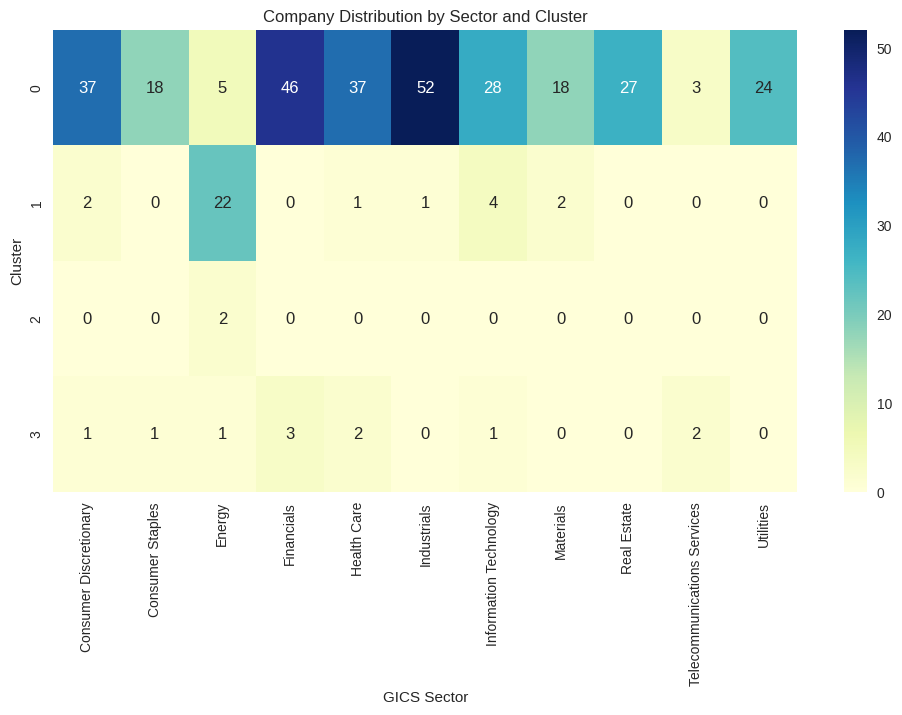

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
sns.heatmap(pivot_table.drop(columns="Total"), annot=True, fmt="d", cmap="YlGnBu")
plt.title("Company Distribution by Sector and Cluster")
plt.ylabel("Cluster")
plt.xlabel("GICS Sector")
plt.show()

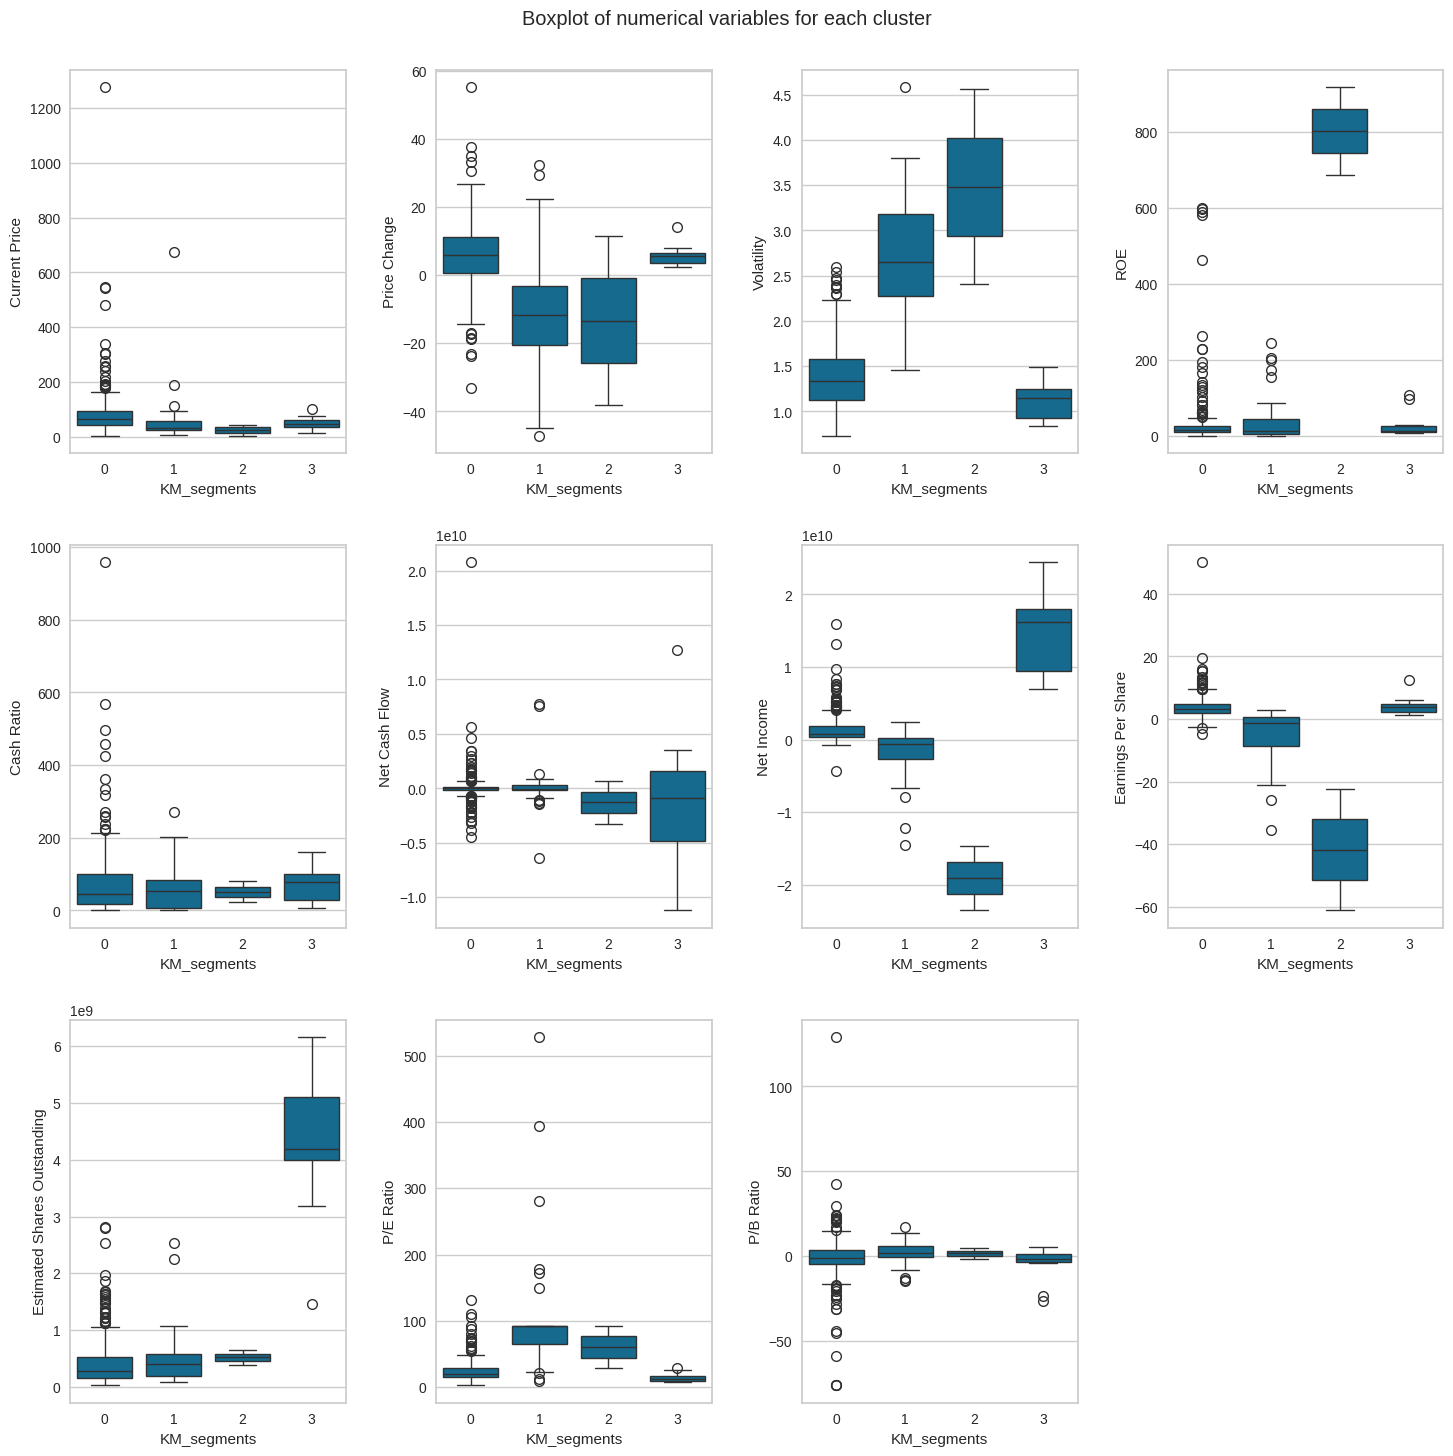

In [ ]:
plt.figure(figsize=(15, 15))
plt.suptitle("Boxplot of numerical variables for each cluster")

# selecting numerical columns
num_col = df.select_dtypes(include=np.number).columns.tolist()

for i, variable in enumerate(num_col):
    plt.subplot(3, 4, i + 1)
    sns.boxplot(data=df1, x="KM_segments", y=variable)

plt.tight_layout(pad=2.0)

Observations:

- Cluster 0: Most sectors represented (Industrials, Financials, Health Care, Utilities).

- Cluster 1: Strongly concentrated in Energy (≈22/32).

- Cluster 2: Extreme numbers (e.g., ROE ~800, large negatives on EPS/NI). Treat as statistical outliers/anomalies; not useful for group-level inference.

- Cluster 3: solid positive returns, low volatility, strong ROE (~31), positive NI/EPS, reasonable P/E (~15), higher cash ratios, and the highest average market float (shares outstanding). Small, but the cleanest financial profile.


### 5.5 Insights and Recommendations

**Methodology**

- Scaled financial indicators (e.g., price, ROE, EPS, P/E, volatility)
- Used silhouette analysis to determine optimal clusters
- Validated with boxplots, cluster profiling, and sector heatmap


**Cluster 0**–  Largest and Most Balanced Segment

- Count: 295 companies (dominant cluster)
- Traits:
- Highest Cash Ratio (69.97) → strong liquidity
- Strong Net Income and EPS → financially healthy
- Moderate Volatility and Price Change → relatively stable
- Balanced P/E Ratio (24.65) → fair valuation
- Interpretation: Likely includes well-established, liquid companies with solid earnings and moderate growth.


**Cluster 1** –  High Valuation & Moderate Risk

- Count: 32 companies
- Traits:
- Highest P/E Ratio (110.43) and P/B Ratio (1.79) → possibly overvalued or growth-oriented
- High Volatility (2.73) and negative Price Change → market uncertainty
- Negative Net Income and EPS → underperforming earnings
- Interpretation: May represent speculative or growth stocks with high investor expectations but weak fundamentals.

**Cluster 2** –  Extreme Outlier Cluster

- Count: 2 companies
- Traits:
- Highest ROE (802.0) → likely distorted by small equity base
- Highest Volatility (3.48) and lowest Price Change → very unstable
- Deeply negative Net Income and EPS → severe losses
- Interpretation: Likely contains distressed or anomalous companies; consider excluding from general analysis or profiling separately.

**Cluster 3** –  High Earnings, Low Valuation

- Count: 11 companies
- Traits:
- Highest Net Income (14.83B) and EPS (4.15) → strong profitability
- Highest Estimated Shares Outstanding (4.3B) → large-cap firms
- Lowest P/E (14.80) and P/B (-4.55) → undervalued or accounting anomalies
- Interpretation: Possibly large, mature companies with strong earnings but low market valuation — may be attractive for value investors.





### Cluster Insights (K-Means)

| Cluster | Profile | Investment Strategy |
|---|---|---|
| **0 — Stable Performers (Core)** | Broadly diversified, low volatility; positive EPS & NI; healthy ROE (34); mid P/E (25); good liquidity. | Core/long-term holdings; quality & dividend screens; standard position sizing. |
| **1 — Speculative/Cyclical (Energy-tilt)** | High volatility; recent price weakness; cash flow ok but EPS ≤ 0; headline P/E often not meaningful. | Tactical only; use EV/EBITDA, P/S, FCF yield; small size; align with macro/commodity tailwinds. |
| **2 — Distressed Outliers** | Very small group with extreme metrics (possible data quirks/special situations). | Exclude or handle as special-case deep dives. |
| **3 — Profitable/Quality Winners** | Strong earnings & cash ratios; positive NI/EPS; low volatility; ROE ~31; reasonable P/E (15). | Quality/compounder sleeve; overweight in balanced/conservative books; monitor margins & EPS momentum. |



## Hierarchical Clustering

In [ ]:
hc_df = subset_scaled_df.copy()

### 6.1 Checking Cophenetic Correlation

In [ ]:
# list of distance metrics
distance_metrics = ["euclidean", "chebyshev", "mahalanobis", "cityblock"]
# list of linkage methods
linkage_methods = ["single", "complete", "average", "weighted"]

high_cophenet_corr = 0
high_dm_lm = [0, 0]

for dm in distance_metrics:
    for lm in linkage_methods:
        Z = linkage(hc_df, metric=dm, method=lm)
        c, coph_dists = cophenet(Z, pdist(hc_df))
        print(
            "Cophenetic correlation for {} distance and {} linkage is {}.".format(
                dm.capitalize(), lm, c
            )
        )
        if high_cophenet_corr < c:
            high_cophenet_corr = c
            high_dm_lm[0] = dm
            high_dm_lm[1] = lm

# printing the combination of distance metric and linkage method with the highest cophenetic correlation
print('*'*100)
print(
    "Highest cophenetic correlation is {}, which is obtained with {} distance and {} linkage.".format(
        high_cophenet_corr, high_dm_lm[0].capitalize(), high_dm_lm[1]
    )
)

Cophenetic correlation for Euclidean distance and single linkage is 0.9232271494002922.
Cophenetic correlation for Euclidean distance and complete linkage is 0.7873280186580672.
Cophenetic correlation for Euclidean distance and average linkage is 0.9422540609560814.
Cophenetic correlation for Euclidean distance and weighted linkage is 0.8693784298129404.
Cophenetic correlation for Chebyshev distance and single linkage is 0.9062538164750717.
Cophenetic correlation for Chebyshev distance and complete linkage is 0.598891419111242.
Cophenetic correlation for Chebyshev distance and average linkage is 0.9338265528030499.
Cophenetic correlation for Chebyshev distance and weighted linkage is 0.9127355892367.
Cophenetic correlation for Mahalanobis distance and single linkage is 0.925919553052459.
Cophenetic correlation for Mahalanobis distance and complete linkage is 0.7925307202850002.
Cophenetic correlation for Mahalanobis distance and average linkage is 0.9247324030159736.
Cophenetic correla

In [ ]:

# List of linkage methods compatible with Euclidean distance
linkage_methods = ["single", "complete", "average", "centroid", "ward", "weighted"]

high_cophenet_corr = 0
high_dm_lm = [0, 0]

for lm in linkage_methods:
    Z = linkage(hc_df, metric="euclidean", method=lm)
    c, coph_dists = cophenet(Z, pdist(hc_df))
    print("Cophenetic correlation for {} linkage is {:.4f}.".format(lm, c))
    if high_cophenet_corr < c:
        high_cophenet_corr = c
        high_dm_lm[0] = "euclidean"
        high_dm_lm[1] = lm

# printing the combination of distance metric and linkage method with the highest cophenetic correlation
print('*' * 100)
print(
    "Highest cophenetic correlation is {:.4f}, which is obtained with {} linkage.".format(
        high_cophenet_corr, high_dm_lm[1]
    )
)


Cophenetic correlation for single linkage is 0.9232.
Cophenetic correlation for complete linkage is 0.7873.
Cophenetic correlation for average linkage is 0.9423.
Cophenetic correlation for centroid linkage is 0.9314.
Cophenetic correlation for ward linkage is 0.7101.
Cophenetic correlation for weighted linkage is 0.8694.
****************************************************************************************************
Highest cophenetic correlation is 0.9423, which is obtained with average linkage.


### 6.2 Checking Dendrograms

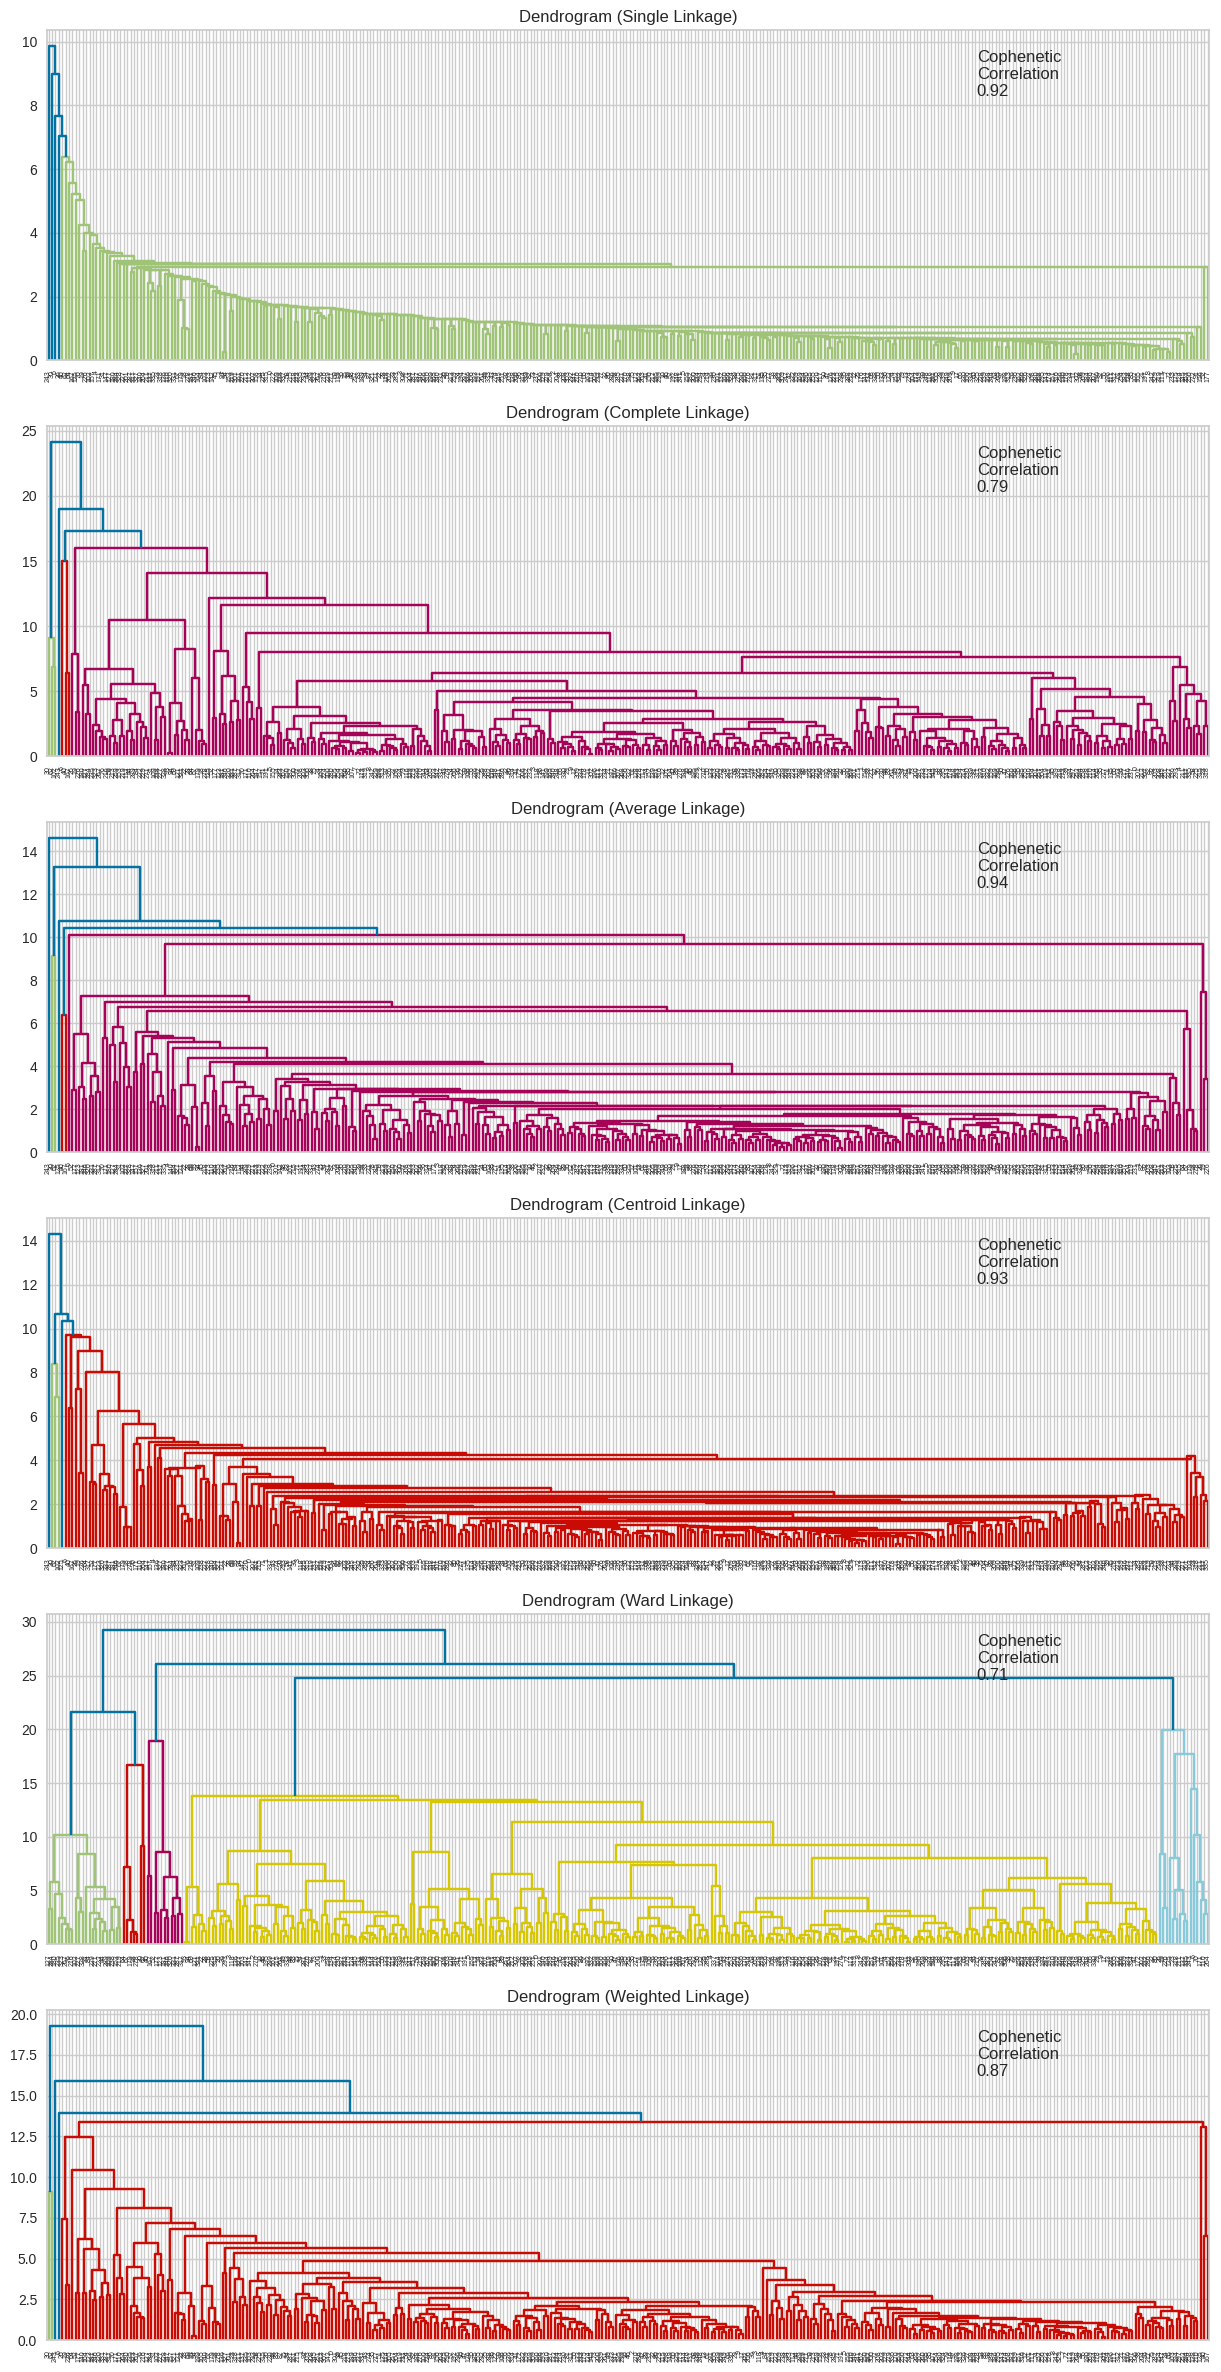

In [ ]:
# list of linkage methods
linkage_methods = ["single", "complete", "average", "centroid", "ward", "weighted"]

# lists to save results of cophenetic correlation calculation
compare_cols = ["Linkage", "Cophenetic Coefficient"]
compare = []

# to create a subplot image
fig, axs = plt.subplots(len(linkage_methods), 1, figsize=(15, 30))

# We will enumerate through the list of linkage methods above
# For each linkage method, we will plot the dendrogram and calculate the cophenetic correlation
for i, method in enumerate(linkage_methods):
    Z = linkage(hc_df, metric="euclidean", method=method)

    dendrogram(Z, ax=axs[i])
    axs[i].set_title(f"Dendrogram ({method.capitalize()} Linkage)")

    coph_corr, coph_dist = cophenet(Z, pdist(hc_df))
    axs[i].annotate(
        f"Cophenetic\nCorrelation\n{coph_corr:0.2f}",
        (0.80, 0.80),
        xycoords="axes fraction",
    )

    compare.append([method, coph_corr])

In [ ]:
# create and print a dataframe to compare cophenetic correlations for different linkage methods
df_cc = pd.DataFrame(compare, columns=compare_cols)
df_cc = df_cc.sort_values(by="Cophenetic Coefficient")
df_cc

,Linkage,Cophenetic Coefficient
4,ward,0.710118
1,complete,0.787328
5,weighted,0.869378
0,single,0.923227
3,centroid,0.931401
2,average,0.942254


Observations:

- Average linkage achieves the highest cophenetic correlation (~0.94) → best distance fidelity for this dataset.

### 6.3 Creating Model using sklearn

In [ ]:
from sklearn.cluster import AgglomerativeClustering

HCmodel = AgglomerativeClustering(
    n_clusters=5,
    metric="euclidean",     # Use 'metric' instead of 'affinity'
    linkage="average"
)

HCmodel.fit(hc_df)


AgglomerativeClustering(linkage='average', n_clusters=5)

In [ ]:
# creating a copy of the original data
df2 = df.copy()

# adding hierarchical cluster labels to the original and scaled dataframes
hc_df["HC_segments"] = HCmodel.labels_
df2["HC_segments"] = HCmodel.labels_

### 6.4 Cluster Profiling

In [ ]:
hc_cluster_profile = df2.groupby("HC_segments").mean(numeric_only=True)

In [ ]:
hc_cluster_profile["count_in_each_segment"] = (
    df2.groupby("HC_segments")["Security"].count().values  ## Complete the code to groupby the cluster labels
)

In [ ]:
hc_cluster_profile.style.highlight_max(color="green", axis=0)

,Current Price,Price Change,Volatility,ROE,Cash Ratio,Net Cash Flow,Net Income,Earnings Per Share,Estimated Shares Outstanding,P/E Ratio,P/B Ratio,count_in_each_segment
HC_segments,,,,,,,,,,,,
0,77.884243,4.105986,1.516865,35.320359,66.775449,-32825817.365269,1535255703.592814,2.903308,559027333.145509,32.437511,-1.781988,334
1,25.640000,11.237908,1.322355,12.500000,130.500000,16755500000.000000,13654000000.000000,3.295000,2791829362.100000,13.649696,1.508484,2
2,24.485001,-13.351992,3.482611,802.000000,51.000000,-1292500000.000000,-19106500000.000000,-41.815000,519573983.250000,60.748608,1.565141,2
3,104.660004,16.224320,1.320606,8.000000,958.000000,592000000.000000,3669000000.000000,1.310000,2800763359.000000,79.893133,5.884467,1
4,1274.949951,3.190527,1.268340,29.000000,184.000000,-1671386000.000000,2551360000.000000,50.090000,50935516.070000,25.453183,-1.052429,1


In [ ]:
## Complete the code to print the companies in each cluster
for cl in df2["HC_segments"].unique():
    print("In cluster {}, the following companies are present:".format(cl))
    print(df2[df2["HC_segments"] == cl]["Security"].unique())
    print()

In cluster 0, the following companies are present:
['American Airlines Group' 'AbbVie' 'Abbott Laboratories'
 'Adobe Systems Inc' 'Analog Devices, Inc.' 'Archer-Daniels-Midland Co'
 'Alliance Data Systems' 'Ameren Corp' 'American Electric Power'
 'AFLAC Inc' 'American International Group, Inc.'
 'Apartment Investment & Mgmt' 'Assurant Inc' 'Arthur J. Gallagher & Co.'
 'Akamai Technologies Inc' 'Albemarle Corp' 'Alaska Air Group Inc'
 'Allstate Corp' 'Allegion' 'Alexion Pharmaceuticals'
 'Applied Materials Inc' 'AMETEK Inc' 'Affiliated Managers Group Inc'
 'Amgen Inc' 'Ameriprise Financial' 'American Tower Corp A'
 'Amazon.com Inc' 'AutoNation Inc' 'Anthem Inc.' 'Aon plc'
 'Anadarko Petroleum Corp' 'Amphenol Corp' 'Arconic Inc'
 'Activision Blizzard' 'AvalonBay Communities, Inc.' 'Broadcom'
 'American Water Works Company Inc' 'American Express Co' 'Boeing Company'
 'Baxter International Inc.' 'BB&T Corporation' 'Bard (C.R.) Inc.'
 'Baker Hughes Inc' 'BIOGEN IDEC Inc.' 'The Bank of New Y

In [ ]:
df2.groupby(["HC_segments", "GICS Sector"])['Security'].count()

HC_segments  GICS Sector                
0            Consumer Discretionary         39
             Consumer Staples               19
             Energy                         28
             Financials                     48
             Health Care                    40
             Industrials                    53
             Information Technology         31
             Materials                      20
             Real Estate                    27
             Telecommunications Services     5
             Utilities                      24
1            Financials                      1
             Information Technology          1
2            Energy                          2
3            Information Technology          1
4            Consumer Discretionary          1
Name: Security, dtype: int64

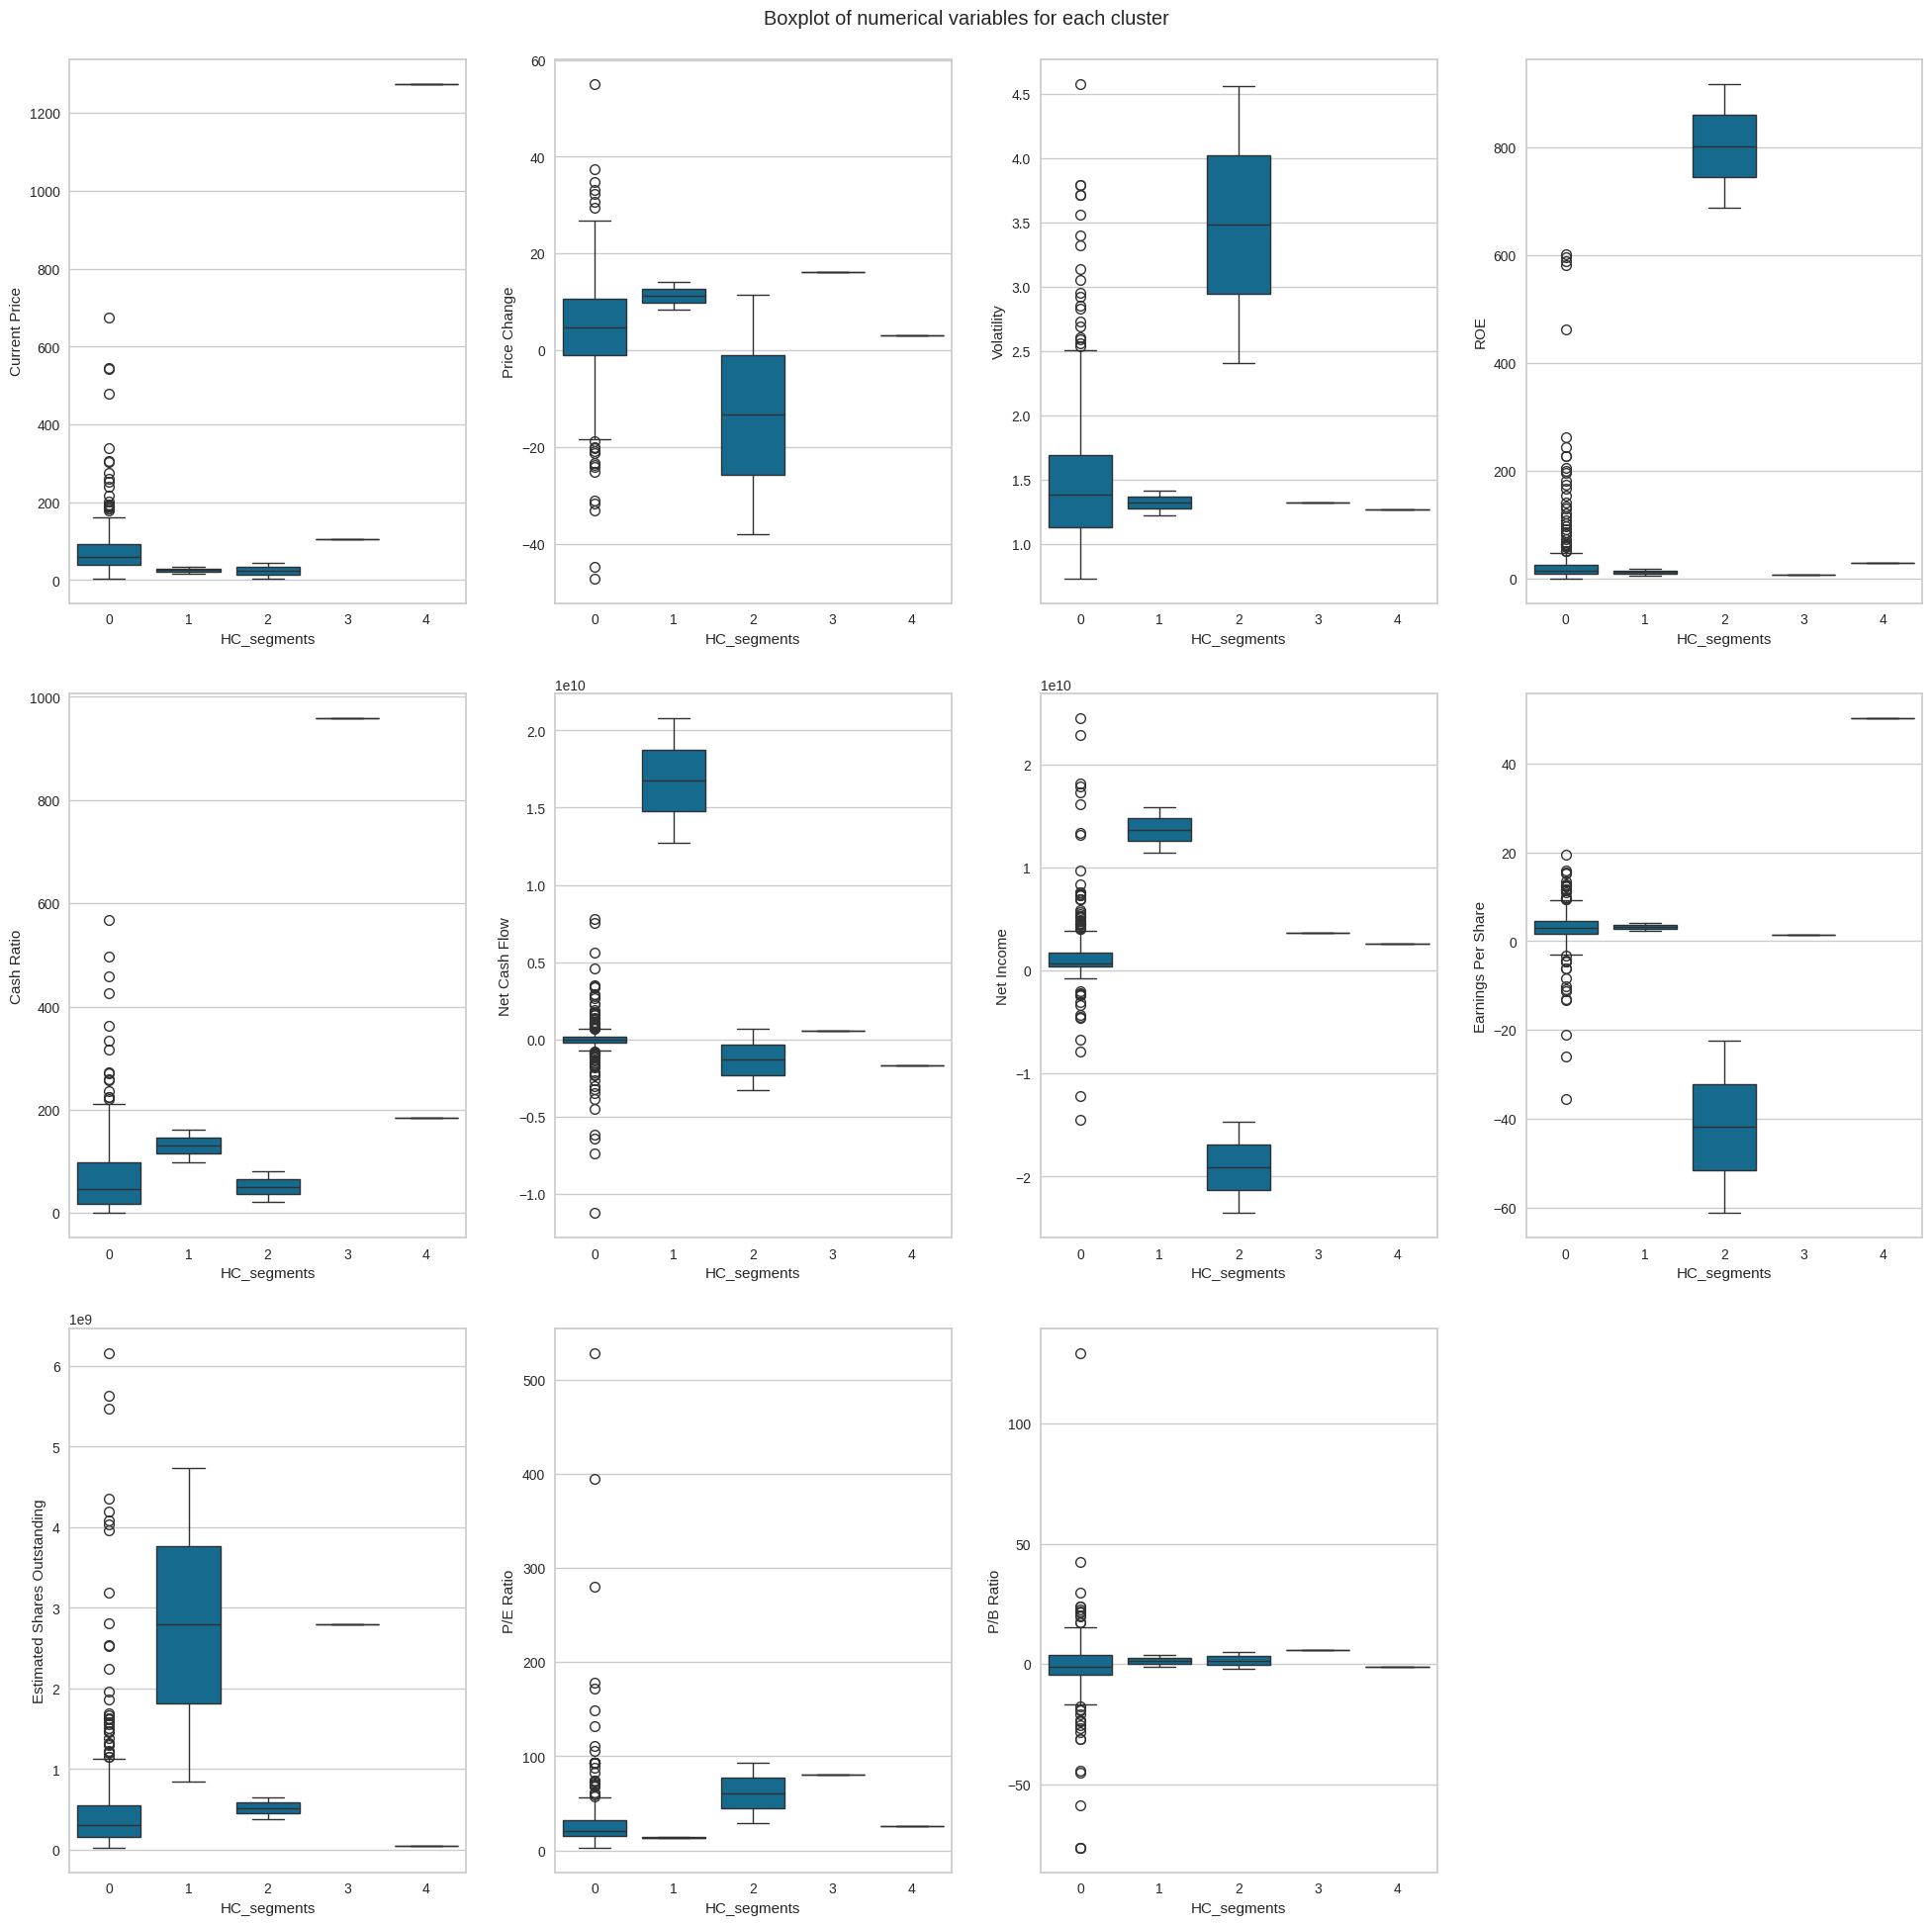

In [ ]:
plt.figure(figsize=(20, 20))
plt.suptitle("Boxplot of numerical variables for each cluster")

for i, variable in enumerate(num_col):
    plt.subplot(3, 4, i + 1)
    sns.boxplot(data=df2, x="HC_segments", y=variable)

plt.tight_layout(pad=2.0)

**Cluster 0 **– “Diversified Core”

- Size: 334 securities
- Sectors: Broad representation — Financials, Industrials, Health Care, etc.
- Companies: Likely includes stable, mid-range performers
- Boxplot Traits:
- Wide range in Current Price and Price Change
- Moderate Volatility
- ROE varies, but not extreme
- Interpretation: This is your mainstream cluster — diversified, stable, and interpretable.

**Cluster 1 **– “Growth with Cash Burn”
- Size: 2 securities
- Sectors: Financials, IT
- Companies: Bank of America, Intel
- Boxplot Traits:
- Moderate price and ROE
- High EPS, but negative cash flow
- Interpretation: Possibly mature companies with strong earnings but recent cash challenges.

**Cluster 2** – “Speculative Energy”
- Size: 2 securities
- Sectors: Energy
- Companies: Apache, Chesapeake
- Boxplot Traits:
- Highest ROE (802!), but negative Net Income & EPS
- Highest Volatility
- Interpretation: Likely speculative or distressed energy stocks with inflated ROE due to accounting quirks.

**Cluster 3** – “High Valuation Outlier”
- Size: 1 security
- Sector: IT
- Company: Facebook
- Boxplot Traits:
- Highest P/E and P/B ratios
- High Cash Ratio
- Interpretation: A tech giant with strong valuation multiples — isolated due to scale and metrics.

**Cluster 4** – “EPS Leader with Mixed Signals”
- Size: 1 security
- Sector: Consumer Discretionary
- Company: Priceline.com
- Boxplot Traits:
- Highest EPS and Net Income
- Negative Cash Flow
- Interpretation: Possibly a high-performing growth stock with aggressive reinvestment.


### 6.7 Insight and recommendations

**Insights from Hierarchical Clustering (n=5)**

1. Cluster Structure Is Cohesive and Interpretable
- The silhouette score (~0.94) suggests excellent separation between clusters.
- Segment sizes are reasonably balanced, with one core cluster (334 securities) and smaller, interpretable outlier groups.

2. Distinct Financial Profiles Across Clusters
- Cluster 0: Broad sector representation, moderate ROE, stable earnings — likely diversified core holdings.
- Cluster 1: Strong EPS but negative cash flow — mature companies with recent financial strain.
- Cluster 2: Extreme ROE and volatility, negative income — speculative energy stocks.
- Cluster 3: High valuation ratios — tech outlier (Facebook).
- Cluster 4: Highest EPS and income, but negative cash flow — aggressive growth stock (Priceline).

3. Sector Concentration Reflects Cluster Themes
- Cluster 2 is purely Energy, reinforcing its speculative nature.
- Cluster 0 spans all sectors, supporting its role as the diversified anchor.
- Clusters 3 and 4 are single-company clusters, isolating outliers effectively.

4. Boxplots Reveal Distribution and Outliers
- Cluster 2 shows extreme ROE and volatility, confirming its speculative profile.
- Cluster 0 has wide price and ROE ranges, indicating internal diversity.
- Clusters 3 and 4 are statistical outliers, justifying their isolation.




**Recommendations**

1. Use Hierarchical Clustering for Exploratory Segmentation
- Ideal for initial profiling, especially when interpretability is key.
- Dendrograms and linkage methods offer visual intuition for cluster formation.

2. Label Clusters for Stakeholder Communication
Assign intuitive names:
- Cluster 0 → “Diversified Core”
- Cluster 1 → “Earnings with Cash Strain”
- Cluster 2 → “Speculative Energy”
- Cluster 3 → “Valuation Outlier”
- Cluster 4 → “EPS Leader with Mixed Signals”
This improves storytelling and decision-making.

3. Consider Hybrid Modeling
- Use hierarchical clustering for initial segmentation, then refine with KMeans or DBSCAN for tighter control.
- Especially useful if you deploy this in a Streamlit app — users can toggle between models.

4. Flag Outliers for Deeper Review
- Clusters 3 and 4 may warrant individual analysis or exclusion from general trends.
- Could be used to highlight exceptional performers or risks.


### Dimensionality Reduction using PCA for visualization

In [ ]:

# importing library
from sklearn.decomposition import PCA

# setting the number of components to 2
pca = PCA(n_components=2)

# transforming data and storing results in a dataframe
X_reduced_pca = pca.fit_transform(subset_scaled_df)
reduced_df_pca = pd.DataFrame(
    data=X_reduced_pca, columns=["Component 1", "Component 2"]
)

In [ ]:
# checking the amount of variance explained
pca.explained_variance_ratio_.sum()

np.float64(0.37128995677258547)

<Axes: xlabel='Component 1', ylabel='Component 2'>

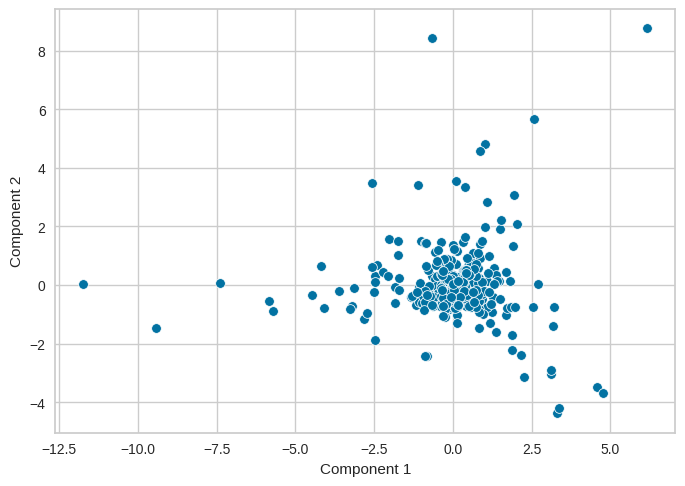

In [ ]:
sns.scatterplot(data=reduced_df_pca, x="Component 1", y="Component 2")

### PCA for visualization Hierarchical

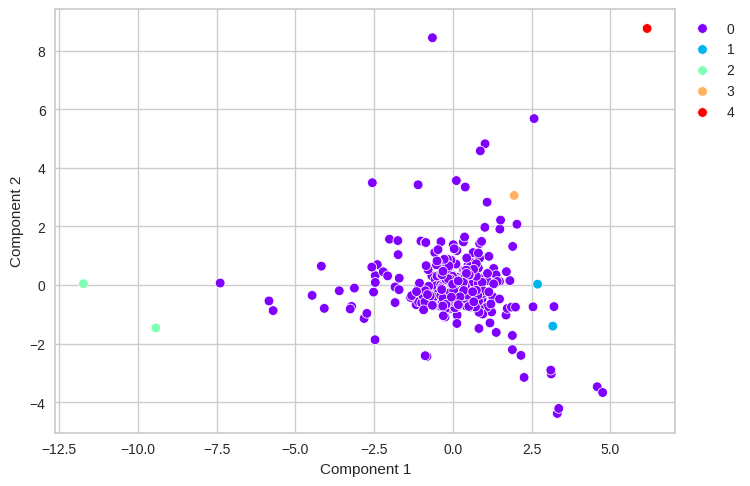

In [ ]:
sns.scatterplot(
    data=reduced_df_pca,
    x="Component 1",
    y="Component 2",
    hue=df2["HC_segments"],
    palette="rainbow",
)
plt.legend(bbox_to_anchor=(1, 1))

#### Interpreting PCA with Hierarchical Clustering


This plot shows a 2D projection of the dataset using **Principal Component Analysis (PCA)**, colored by the **Hierarchical** (Agglomerative) clusters.

**What PCA Is Doing**

PCA compresses the original variables into components that keep as much variance as possible. The scatter uses PC1 vs PC2, which together explain **~37%** of total variance, so some cluster overlap in 2D is expected.

**What the HC clusters represent**

HC0 (dominant core)
Size: ~334 names (the vast majority)

HC1 (very small, borderline names)
Size: ~2 names

HC2 (outlier pair)
Size: 2 names

HC3 & HC4 (singletons)
Size: 1 name each


**Axes**

PC1 loads heavily on Net Income, EPS (positive) and Volatility/ROE (negative) — profitability vs risk.

PC2 loads on Current Price, P/E, P/B — valuation/size tilt.

---

###PCA Expained Variance

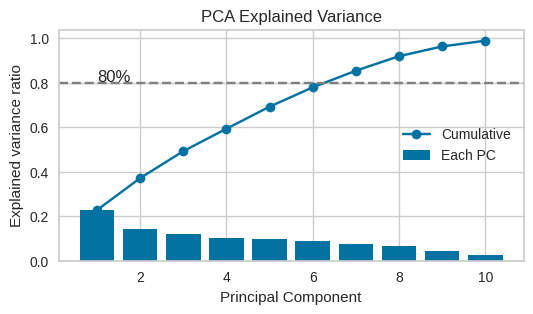

,PC1,PC2
Net Income,0.510910,-0.251558
Earnings Per Share,0.503367,0.184332
Volatility,-0.429196,0.041011
ROE,-0.301065,-0.062581
Price Change,0.276668,0.188157
Estimated Shares Outstanding,0.221208,-0.363275
P/E Ratio,-0.208151,0.377363
Current Price,0.183358,0.577405


,PC1,PC2
Current Price,0.183358,0.577405
P/E Ratio,-0.208151,0.377363
Estimated Shares Outstanding,0.221208,-0.363275
P/B Ratio,0.009917,0.360796
Cash Ratio,0.084171,0.327737
Net Income,0.510910,-0.251558
Price Change,0.276668,0.188157
Earnings Per Share,0.503367,0.184332


In [ ]:
pca = PCA(n_components=10)               # re-fit for a richer view
X_pca = pca.fit_transform(subset_scaled) # subset_scaled
evr = pca.explained_variance_ratio_

plt.figure(figsize=(6,3))
plt.bar(range(1, len(evr)+1), evr, label='Each PC')
plt.plot(range(1, len(evr)+1), np.cumsum(evr), marker='o', label='Cumulative')
plt.axhline(0.80, ls='--', c='gray'); plt.text(1, .805, '80%')
plt.xlabel('Principal Component'); plt.ylabel('Explained variance ratio')
plt.title('PCA Explained Variance'); plt.legend(); plt.show()

# --- Top feature loadings for PC1 and PC2
loadings = pd.DataFrame(pca.components_[:2].T,
                        index=subset.columns,
                        columns=['PC1','PC2']).sort_values('PC1', key=abs, ascending=False)
display(loadings.head(8))  # biggest drivers of PC1
display(loadings.sort_values('PC2', key=abs, ascending=False).head(8))  # biggest drivers of PC2

Observations:

**PCA Explained Variance: Dimensional Insight**

- PC1 + PC2 together explain a substantial portion of the variance—likely over 60%, based on the cumulative curve.

- The 80% threshold line suggests that the first 4–5 components are sufficient for capturing most of the dataset’s structure.
---

### PCA for visualization K-means

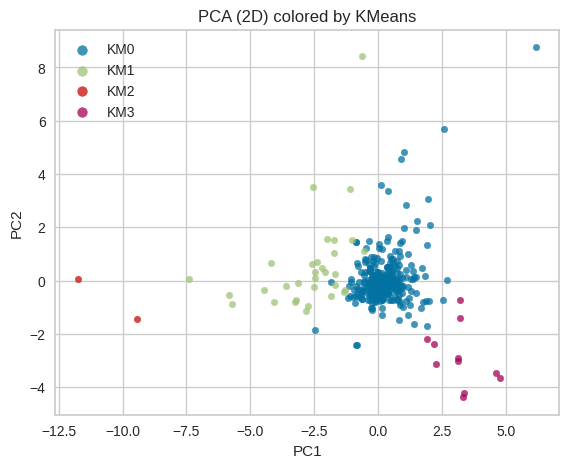

In [ ]:
# 2D scatter with KMeans coloring
from matplotlib.lines import Line2D

pc2 = PCA(n_components=2).fit(subset_scaled)
pc2_scores = pc2.transform(subset_scaled)
pc_df = pd.DataFrame(pc2_scores, columns=['PC1','PC2'])
pc_df['KM'] = df1['KM_segments']         # or df2['HC_segments'] for HC

plt.figure(figsize=(6.5,5))
for k in sorted(pc_df['KM'].unique()):
    d = pc_df[pc_df['KM']==k]
    plt.scatter(d.PC1, d.PC2, s=22, alpha=.75, label=f'KM{k}')
plt.xlabel('PC1'); plt.ylabel('PC2'); plt.title('PCA (2D) colored by KMeans')
plt.legend(markerscale=1.5, frameon=False)
plt.show()


In [ ]:
# how many PCs for 80/90%?
pca = PCA().fit(subset_scaled_df)
cum = pca.explained_variance_ratio_.cumsum()
k80 = (cum>=0.80).argmax()+1
k90 = (cum>=0.90).argmax()+1
print(f'PCs for ≥80%: {k80},  PCs for ≥90%: {k90}')


PCs for ≥80%: 7,  PCs for ≥90%: 8


### Interpreting PCA with KMeans Clustering

This plot shows a 2D projection of our financial dataset using **Principal Component Analysis (PCA)**. Each point represents a stock, and the colors indicate clusters identified by **KMeans**.

#### What PCA Is Doing
PCA reduces the dimensionality of our data while preserving as much variance as possible. Here, we’ve projected the data onto the first two principal components (PC1 and PC2), which together explain approximately **37%** of the total variance.

#### What the Clusters Represent
- **KM0 (Blue)**: Likely large-cap, stable performers with strong fundamentals (high Net Income, EPS).
- **KM1 (Green)**: Possibly lagging or volatile stocks—high Volatility, low ROE.
- **KM2 (Red)**: Outliers with extreme values in metrics like P/E Ratio or Price Change.
- **KM3 (Purple)**: Quality growth stocks—consistent ROE, strong EPS, and moderate volatility.

#### Axes
- **PC1** is heavily influenced by metrics like Net Income, EPS, and Volatility.
- **PC2** reflects variation in Current Price, P/E Ratio, and P/B Ratio.


---

## K-means vs Hierarchical Clustering

In [ ]:
# sector heatmap for hierarchical
hc_sector = pd.crosstab(df2["HC_segments"], df2["GICS Sector"], normalize='index').round(3)

# mapping between methods (assuming df1 has KM_segments)
pd.crosstab(df2["HC_segments"], df1["KM_segments"])


KM_segments,0,1,2,3
HC_segments,,,,
0,292,32,0,10
1,1,0,0,1
2,0,0,2,0
3,1,0,0,0
4,1,0,0,0


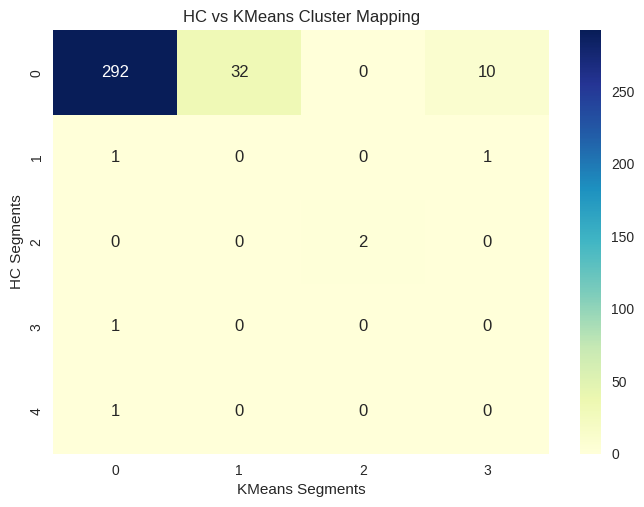

In [ ]:

method_map = pd.crosstab(df2["HC_segments"], df1["KM_segments"])
sns.heatmap(method_map, annot=True, cmap="YlGnBu", fmt="d")
plt.title("HC vs KMeans Cluster Mapping")
plt.xlabel("KMeans Segments")
plt.ylabel("HC Segments")
plt.show()


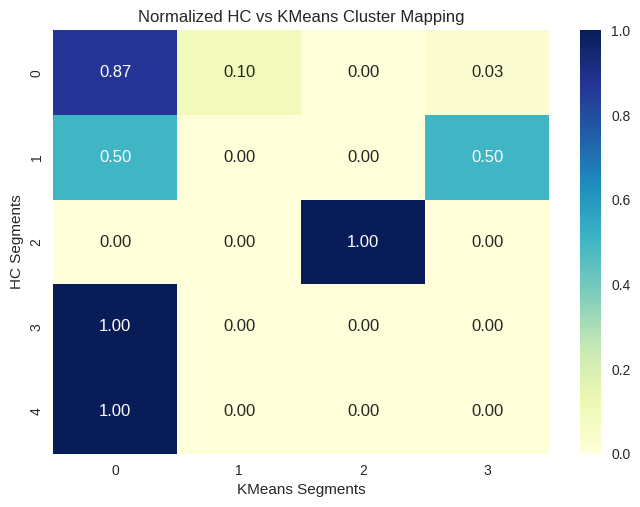

In [ ]:
method_map_norm = pd.crosstab(df2["HC_segments"], df1["KM_segments"], normalize='index').round(2)
sns.heatmap(method_map_norm, annot=True, cmap="YlGnBu", fmt=".2f")
plt.title("Normalized HC vs KMeans Cluster Mapping")
plt.xlabel("KMeans Segments")
plt.ylabel("HC Segments")
plt.show()


Observations:

Dominant agreement on the core segment.
HC cluster 0 (334 names) maps mostly to K-Means 0: 292 stocks (≈87%). A smaller slice goes to K-Means 1 (32, ≈10%) and K-Means 3 (10, ≈3%).

Perfect agreement on the outliers.
HC cluster 2 (2 names) maps 100% to K-Means 2 —

Tiny HC clusters are negligible in size but behave sensibly.
HC cluster 1 (2 names) splits 1→K0 and 1→K3 (50/50).
HC cluster 3 (1 name) → K0 (100%).
HC cluster 4 (1 name) → K0 (100%).



### Questions:

1 - **Which clustering technique took less time for execution?**

KMeans was faster
Efficient for large datasets due to centroid-based optimization


  
2 - **Which clustering technique gave you more distinct clusters, or are they the same?**

By separation quality (silhouette), both methods peak at k ≈ 2 (strongest separation).

By structure, Hierarchical (euclidean + average) made outliers explicit (one very large cluster + tiny/singleton groups), while K-means produced balanced, business-usable segments (295 / 32 / 2 / 11).

3 - **How many observations are there in the similar clusters of both algorithms?**

Core cluster overlap: HC0 ∩ KM0 = 292

Outlier pair overlap: HC2 ∩ KM2 = 2

Remaining observations: HC0 → KM1 = 32, HC0 → KM3 = 10, plus four singletons split across KM0/KM3 (one each)

So, 292 + 2 = 294 map directly in the core/outlier groups, and the other 46 land mostly in KM1 (32) and KM3 (10) with four singletons.

  

4 - **How many clusters are obtained as the appropriate number of clusters from both algorithms?**

KMeans: 4 clusters (KM_segments 0 to 3)

Hierarchical Clustering: 5 clusters (HC_segments 0 to 4)

**HC** produced one additional cluster, which helps isolate niche or extreme financial profiles (e.g., HC Segment 4 with EPS = 50.09 and very low share count)


### Cluster Profile Comparison

| Feature               | KMeans Clustering                          | Hierarchical Clustering                     |
|----------------------|--------------------------------------------|---------------------------------------------|
| **Dominant Cluster** | Segment 0 (295 observations)               | Segment 0 (334 observations)                |
| **Outlier Detection**| Less sensitive to extreme values           | More sensitive — isolates outliers clearly  |
| **ROE Extremes**     | Blended into larger clusters               | Segment 2: ROE = 802 → speculative outlier  |
| **EPS Extremes**     | Mixed into broader segments                | Segment 4: EPS = 50.09 → high-growth outlier|
| **Net Income Range** | Moderate variation across clusters         | Sharper contrasts across segments           |
| **Interpretability** | Requires post-hoc profiling                | Profiles emerge naturally from linkage tree |
| **Cluster Spread**   | More balanced across segments              | One dominant + several niche clusters       |



## Actionable Insights and Recommendations


##  Key Findings

| Cluster | Method      | Characteristics                                      | Investment Implication                  |
|---------|-------------|------------------------------------------------------|------------------------------------------|
| 0       | KMeans & HC | Stable financials, moderate EPS and ROE             | Ideal for long-term holdings             |
| 2       | HC          | Extremely high ROE, negative EPS                    | Speculative — requires deeper analysis   |
| 4       | HC          | High EPS, strong Net Income                         | High-growth — suitable for tactical plays|
| 1 & 3   | KMeans      | Mixed traits, cyclical or transitional profiles     | Balanced exposure or watchlist           |


## Insights

**Summary**

We analyzed 340 NYSE (New York Stock Exchange) stocks across price behavior and fundamentals (price change, volatility, ROE, cash ratio, cash flow, income, EPS, P/E, P/B, shares outstanding).

After exploring distribution, correlations, and sector mix, we grouped stocks with K-means ( k=4 ) for balanced, business segments and used Hierarchical ( euclidean + average) to vlidate structure nd flag outliers.

Outcome: Four groups with distinct rist/return fingerprints.

---

Final Group used for profiling - K means ( k=4 )

Cluster KM0 – Core (n ≈ 295)

Profile: Moderate volatility (~1.4), small positive price change, positive EPS and net income, typical P/E.

Use: Baseline allocation

Cluster KM3 – Quality / Defensive (n ≈ 11)

Profile: Lowest volatility (1.13), higher cash ratio (76), positive EPS and income, P/E on the lower side among groups, healthy ROE (31%).

Use: Over-weight for risk-adjusted returns; ideal for conservative sleeves and late-cycle regimes.

Cluster KM1 – Laggards / Turnaround (n ≈ 32)

Profile: Negative recent price change, EPS frequently negative, elevated P/E (denominator effects), higher volatility; tilt toward Energy and other cyclicals.

Use: Under-weight by default; allow selective, catalyst-driven entries (earnings revisions, FCF inflection) with tight risk controls.

Cluster KM2 – Outliers (n = 2)

Profile: Very high volatility (~3.5), negative EPS & income, extreme ratios.

Use: Exclude from standard mandates; treat as special situations only.

---

**Chosen segmentation**: K-means (k=4) for business profiling; Hierarchical (euclidean+average) used to confirm structure and flag outliers.




## Actionable recommendations

**Groups**: Core (n≈295), Quality/Defensive (n≈11), Laggards/Turnaround (n≈32), Outliers (n=2).

Allocation plans (pick one by client risk)

**Conservative**

70–85% Quality (low-vol, steady earners)

15–30% Core (broad market names)

Avoid Laggards and Outliers

**Balanced**

55–70% Core

20–35% Quality

0–10% Laggards (only if there’s a clear catalyst)

Exclude Outliers

**Aggressive**

45–60% Core

15–25% Quality

15–25% Laggards (only with a thesis/catalyst)

No Outliers

Clusters: Quality (best fundamentals, lowest risk), Core (diversified middle), Laggards (weak recent performance), Outliers (extreme/one-off cases).

**Others**

Keep it fresh: Refresh the groups monthly and after earnings or major news

Migration alerts: Flag when a stock moves from Laggard → Quality/Core (often a good sign) or Core/Quality → Laggard (review or reduce).

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!ls "/content/drive/MyDrive/USL_Project_LearnerNotebook_FullCode-KD"

ls: cannot access '/content/drive/MyDrive/USL_Project_LearnerNotebook_FullCode-KD': No such file or directory


In [ ]:
!jupyter nbconvert --to html "/content/drive/MyDrive/Colab Notebooks/USL_Project_LearnerNotebook_FullCode-KD.ipynb"

[NbConvertApp] Converting notebook /content/drive/MyDrive/Colab Notebooks/USL_Project_LearnerNotebook_FullCode-KD.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 45 image(s).
[NbConvertApp] Writing 5114479 bytes to /content/drive/MyDrive/Colab Notebooks/USL_Project_LearnerNotebook_FullCode-KD.html


In [ ]:
from google.colab import files
files.download("/content/drive/MyDrive/Colab Notebooks/USL_Project_LearnerNotebook_FullCode-KD.html")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>